In [2]:
import utils
import numpy as np
import pandas as pd
import os
import re
from matplotlib.pyplot import cm
import matplotlib.pyplot as plt
import seaborn as sns # Loads in the theme

pd.set_option('future.no_silent_downcasting', True)
#pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', 20)
#pd.set_option('display.width', 1000)

In [3]:
# Make output folder
output_dir = os.path.join('..','..','plots','behavioural', 'objective_performance')
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

In [4]:
# Preparation
pilot_analysis = False
split_dataset = False
plot_range = [0, 6]

if pilot_analysis:
    raw_output_path = '/Volumes/project/3025011.02/pilot_data/phd_1_task/experiment_output/behavioural_files_pilot_2'
    unique_subject_ids = [802,803,804,805,806,808,809,811,813,814,815]
    unique_sessions = [1]
else:
    raw_output_path = '/Volumes/project/3025011.02/raw/'
    unique_subject_ids = [5, 10, 14, 15, 16, 20, 22, 23, 25, 28, 29, 37, 38]#[11, 12, 17, 18, 19, 21, 26, 34, 42]#
    unique_sessions = [2, 3, 4]
    if unique_sessions != [1]:
        split_dataset = True

combined_results_dataframe = utils.import_functions.main(raw_output_path, unique_subject_ids, unique_sessions, pilot_analysis, remove_reversals=False)
combined_results_dataframe.to_csv(os.path.join(output_dir, 'combined_results_kenneth.csv'), index=False, sep=';')
combined_results_dataframe['objectively_correct_boolean'] = combined_results_dataframe['objectively_correct_boolean'] * 100

['/Volumes/project/3025011.02/raw/sub-005/ses-mri02/beh/behavioural_output_sub-005_session-02_skyra_2025-03-14_11-00-23.csv', '/Volumes/project/3025011.02/raw/sub-005/ses-mri03/beh/behavioural_output_sub-005_session-03_skyra_2025-03-21_15-48-02.csv', '/Volumes/project/3025011.02/raw/sub-005/ses-mri04/beh/behavioural_output_sub-005_session-04_skyra_2025-03-28_15-50-17.csv', '/Volumes/project/3025011.02/raw/sub-010/ses-mri02/beh/behavioural_output_sub-010_session-02_skyra_2025-03-13_11-21-05.csv', '/Volumes/project/3025011.02/raw/sub-010/ses-mri03/beh/behavioural_output_sub-010_session-03_skyra_2025-03-19_11-41-24.csv', '/Volumes/project/3025011.02/raw/sub-010/ses-mri04/beh/behavioural_output_sub-010_session-04_skyra_2025-03-25_15-18-37.csv', '/Volumes/project/3025011.02/raw/sub-014/ses-mri02/beh/behavioural_output_sub-014_session-02_skyra_2025-04-01_16-44-40.csv', '/Volumes/project/3025011.02/raw/sub-014/ses-mri03/beh/behavioural_output_sub-014_session-03_skyra_2025-04-08_10-36-56.csv',

# Analysis
First, we'll look at the reaction time. A plot with all the RT's and average will do.
Second we will look at the percentage of correct answers.
Lastly, we will be looking at a win-stay lose shift to see when behaviour stabilises after a shift in reward contingency.

In [5]:
# Count amount of subplots necessary based on subject_id's and sessions
## Finds unique values
unique_subject_ids = combined_results_dataframe['subject_id'].unique()
unique_sessions = combined_results_dataframe['session'].unique()

## Calculates the number of subplots needed
n_rows = len(unique_subject_ids)
n_cols = len(unique_sessions)
n_subplots = len(unique_sessions) * len(unique_subject_ids)

### Split the dataframe
So that combined_results_dataframe has the results you want to analyse but the combined_results_dataframe_all_sessions includes the 1st session as well

In [6]:
if split_dataset:
    combined_results_dataframe_all_sessions = combined_results_dataframe
    combined_results_dataframe = combined_results_dataframe[combined_results_dataframe['session'] != 'session-01']

# Average performance over time

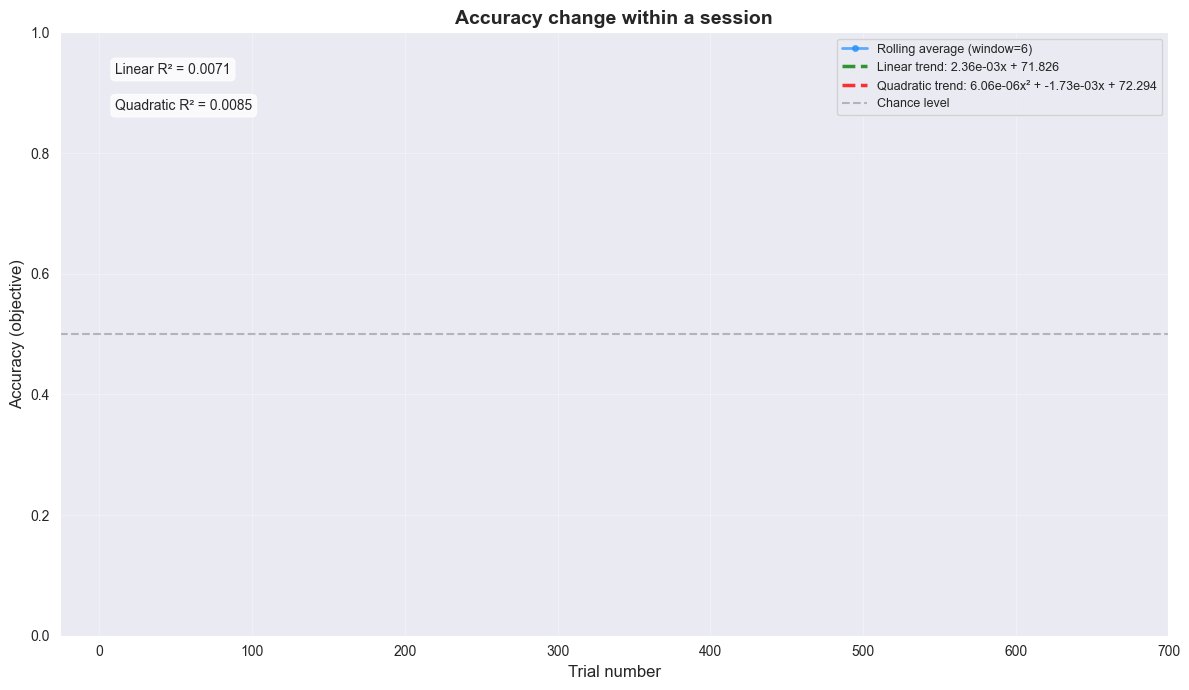

{'rolling_avg_data':      trial  rolling_avg
 0        7    69.945988
 1        8    68.248964
 2        9    70.388645
 3       10    70.060713
 4       11    70.718608
 ..     ...          ...
 656    663    74.016121
 657    664    75.331911
 658    665    76.315789
 659    666    79.473684
 660    667    80.263158
 
 [661 rows x 2 columns],
 'window_size': 6,
 'linear_coef': array([2.35979376e-03, 7.18261428e+01]),
 'linear_r2': 0.007116832843889864,
 'quadratic_coef': array([ 6.06132699e-06, -1.72554063e-03,  7.22938287e+01]),
 'quadratic_r2': 0.008484504287551875}

In [7]:
utils.plotting_functions.plot_average_performance(combined_results_dataframe, output_dir, plot_name='Accuracy change within a session', fit_linear=True, fit_quadratic=True)

# Objectively correct answer binned after every reversal
Sorted for valence

In [8]:
# Create a dataframe with objectively correct responses up to 12 trials since reversal
unique_stimuli_types = combined_results_dataframe['stimuli_type'].unique()
row_index = 0
# Create new plots with different intervals that also contain the 50% trials
mapping = {0: 'subject_id', 1: 'stimuli_type', 2: 'valence', 3: 0, 4: 1, 5: 2, 6: 3, 7: 4, 8: 5, 9: 6, 10: 7, 11: 8, 12: 9, 13: 10}
group_name = 'valence'
unique_group_types = combined_results_dataframe[group_name].unique()


all_reversals_dataframe = utils.analysis_functions.find_reversals_in_dataframe(combined_results_dataframe,
                                                                             unique_subject_ids, unique_stimuli_types,
                                                                             group_name, plot_range, mapping)
print(all_reversals_dataframe)

      subject_id  trial  stimuli_type  probability_condition  reversal valence
0        sub-005      8             1                     20     False   angry
1        sub-005     11             1                     20     False   angry
2        sub-005     12             1                     20     False   angry
3        sub-005     14             1                     20     False   angry
4        sub-005     15             1                     20     False   angry
...          ...    ...           ...                    ...       ...     ...
24843    sub-038    659             2                     20     False   happy
24844    sub-038    660             2                     20     False   happy
24845    sub-038    661             2                     20     False   happy
24846    sub-038    665             2                     20     False   happy
24847    sub-038    666             2                     20     False   happy

[24848 rows x 6 columns]
0    subject_id stimuli_ty

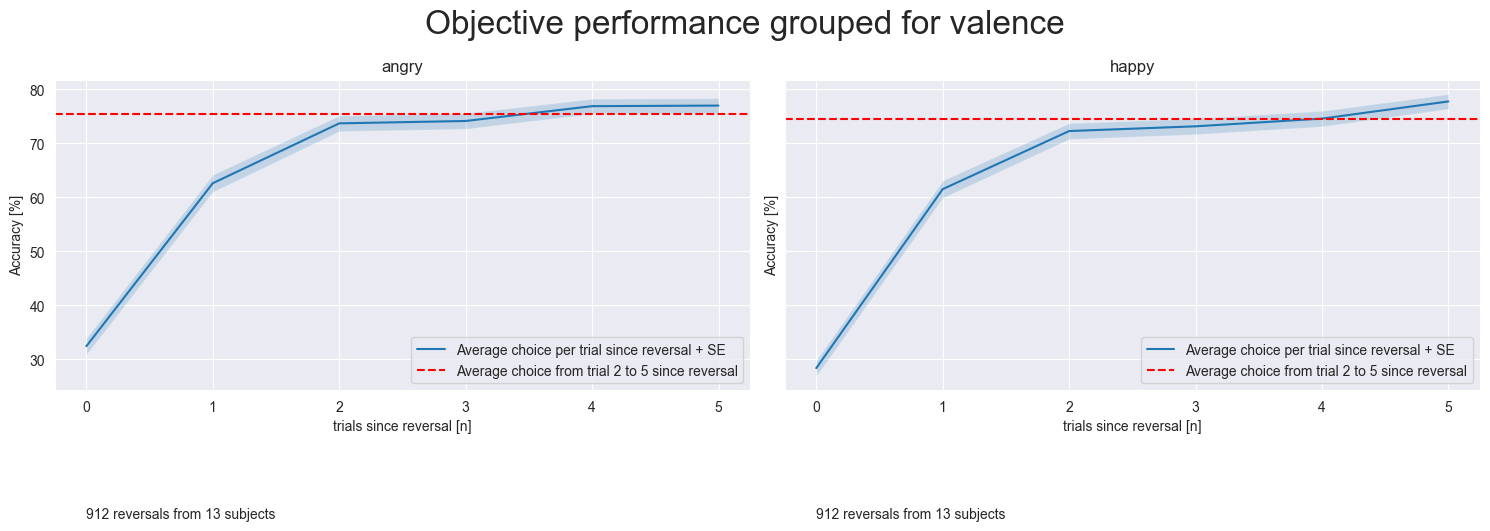

In [9]:
# Prepare the DataFrame by setting 'stimuli_type' as the index temporarily
df = all_reversals_dataframe

subject_counts = len(df['subject_id'].unique())

# Count the number of times both conditions were shown
group_counts = df['valence'].value_counts()

# We are not using 'subject_id', so let's exclude it from our calculations
df = df.drop(columns=['subject_id'])
df = df.drop(columns=['stimuli_type'])

# Calculate the mean and standard deviation for each timepoint and stimuli_type
means = df.groupby(['valence']).mean()
means_overall = means.iloc[:, 2:]
average_choice_after_reversal_total = means_overall.mean(axis=1).tolist()

stds = df.groupby(['valence']).sem()

# Plotting
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15, 6), sharex=True, sharey=True) # Adjust based on the number of stimuli_types
axs = axs.flatten() # Flatten to iterate easily

fig.suptitle('Objective performance grouped for valence', fontsize=24, y=0.982)

congruency_list = df['valence'].unique()

congruency_types = means.index
for i, congruency_type in enumerate(congruency_types):
    # Timepoints are the column names converted to integers for x-axis values
    timepoints = list(range(plot_range[0], plot_range[1]))
    mean_values = means.loc[congruency_type]
    std_values = stds.loc[congruency_type]

    axs[i].plot(timepoints, mean_values, label='Average choice per trial since reversal + SE')
    axs[i].fill_between(timepoints, mean_values - std_values, mean_values + std_values, alpha=0.2)
    axs[i].axhline((average_choice_after_reversal_total[i]), color='r', linestyle='--', label='Average choice from trial 2 to 5 since reversal')
    #axs[i].plot(probability_dataframe_pivoted[i+1].dropna())
    axs[i].set_title(f'{congruency_list[i]}')
    axs[i].set_xlabel('trials since reversal [n]')
    axs[i].set_ylabel('Accuracy [%]')
    axs[i].text(0, 0.66, f'{group_counts[congruency_type]} reversals from {subject_counts} subjects', fontsize=10)
    axs[i].legend()
    axs[i].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'objective_performance_grouped_for_valence.pdf'))
plt.show()

# Now the same but split for congruency

In [10]:
# Create new plots with different intervals that also contain the 50% trials
mapping = {0: 'subject_id', 1: 'stimuli_type', 2: 'congruency', 3: 0, 4: 1, 5: 2, 6: 3, 7: 4, 8: 5, 9: 6}
group_name = 'congruency'
unique_group_types = combined_results_dataframe[group_name].unique()


all_reversals_dataframe = utils.analysis_functions.find_reversals_in_dataframe(combined_results_dataframe,
                                                                             unique_subject_ids, unique_stimuli_types,
                                                                             'congruency', plot_range, mapping)
print(all_reversals_dataframe)

      subject_id  trial  stimuli_type  probability_condition  reversal  \
0        sub-005      8             1                     20     False   
1        sub-005     11             1                     20     False   
2        sub-005     12             1                     20     False   
3        sub-005     14             1                     20     False   
4        sub-005     15             1                     20     False   
...          ...    ...           ...                    ...       ...   
24843    sub-038    659             2                     20     False   
24844    sub-038    660             2                     20     False   
24845    sub-038    661             2                     20     False   
24846    sub-038    665             2                     20     False   
24847    sub-038    666             2                     20     False   

        congruency  
0      incongruent  
1      incongruent  
2      incongruent  
3      incongruent  
4     

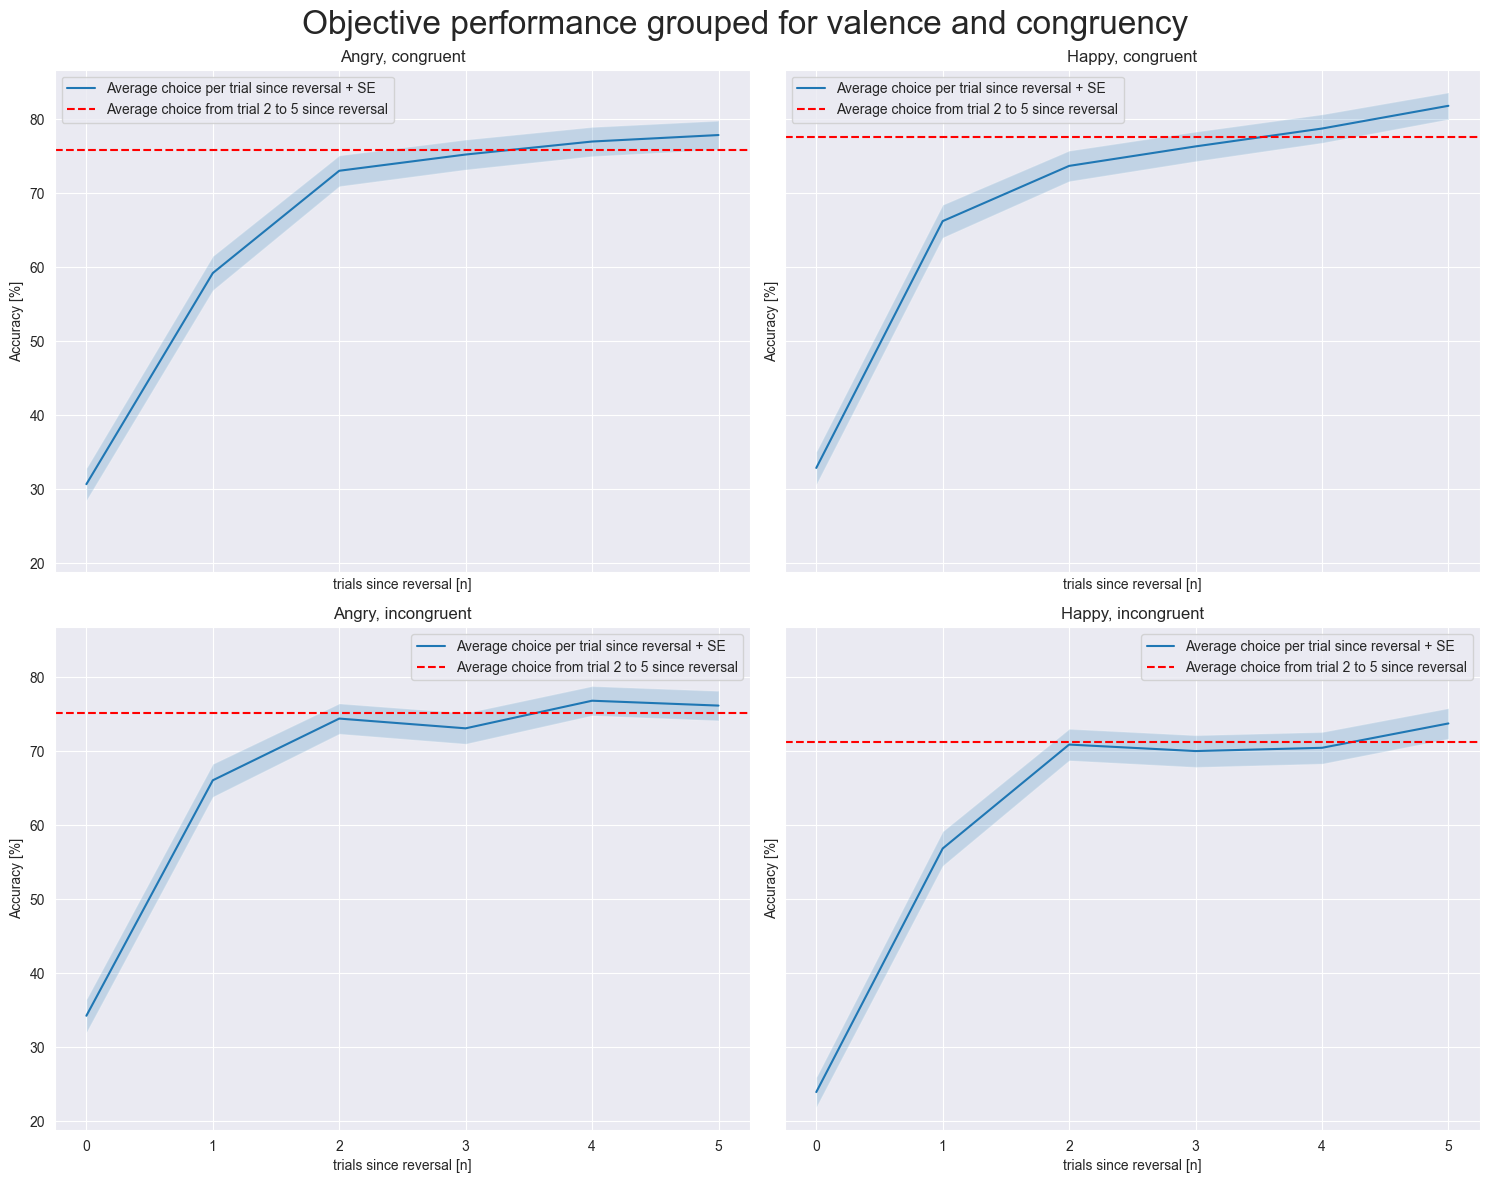

In [11]:
# Prepare the DataFrame by setting 'stimuli_type' as the index temporarily
df = all_reversals_dataframe

# We are not using 'subject_id', so let's exclude it from our calculations
df = df.drop(columns=['subject_id'])

# Calculate the mean and standard deviation for each timepoint and stimuli_type
means = df.groupby(['congruency', 'stimuli_type']).mean()
means_overall = means.iloc[:, 2:]
average_choice_after_reversal_total = means_overall.mean(axis=1).tolist()

stds = df.groupby(['congruency', 'stimuli_type']).sem()

# Plotting
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(15, 12), sharex=True, sharey=True) # Adjust based on the number of stimuli_types
axs = axs.flatten() # Flatten to iterate easily

fig.suptitle('Objective performance grouped for valence and congruency', fontsize=24, y=0.982)

congruency_list = df['congruency'].unique()
stimuli_list = df['stimuli_type'].unique()
stimuli_types_list = ['Angry', 'Angry', 'Happy', 'Happy']

congruency_types = means.index
for i, congruency_type in enumerate(congruency_types):
    # Timepoints are the column names converted to integers for x-axis values
    timepoints = list(range(plot_range[0], plot_range[1]))
    mean_values = means.loc[congruency_type]
    std_values = stds.loc[congruency_type]

    axs[i].plot(timepoints, mean_values, label='Average choice per trial since reversal + SE')
    axs[i].fill_between(timepoints, mean_values - std_values, mean_values + std_values, alpha=0.2)
    axs[i].axhline((average_choice_after_reversal_total[i]), color='r', linestyle='--', label='Average choice from trial 2 to 5 since reversal')
    #axs[i].plot(probability_dataframe_pivoted[i+1].dropna())
    axs[i].set_title(f'{stimuli_types_list[congruency_type[1]]}, {congruency_type[0]}')
    axs[i].set_xlabel('trials since reversal [n]')
    axs[i].set_ylabel('Accuracy [%]')
    axs[i].legend()
    axs[i].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'objective_performance_grouped_for_valence_and_congruency.pdf'))
plt.show()

# Plotting just the responses
As a check to see if giving the two types of responses was equally as difficult

In [12]:
# Create new plots with different intervals that also contain the 50% trials
mapping = {0: 'subject_id', 1: 'stimuli_type', 2: 'response', 3: 0, 4: 1, 5: 2, 6: 3, 7: 4, 8: 5, 9: 6, 10: 7, 11: 8, 12: 9, 13: 10}
group_name = 'response'
unique_group_types = combined_results_dataframe[group_name].unique()


all_reversals_dataframe = utils.analysis_functions.find_reversals_in_dataframe(combined_results_dataframe,
                                                                             unique_subject_ids, unique_stimuli_types,
                                                                             group_name, plot_range, mapping)
print(all_reversals_dataframe)

      subject_id  trial  stimuli_type  probability_condition  reversal  \
0        sub-005      8             1                     20     False   
1        sub-005     11             1                     20     False   
2        sub-005     12             1                     20     False   
3        sub-005     14             1                     20     False   
4        sub-005     15             1                     20     False   
...          ...    ...           ...                    ...       ...   
24843    sub-038    659             2                     20     False   
24844    sub-038    660             2                     20     False   
24845    sub-038    661             2                     20     False   
24846    sub-038    665             2                     20     False   
24847    sub-038    666             2                     20     False   

      response  
0           up  
1           up  
2           up  
3         down  
4         down  
...      

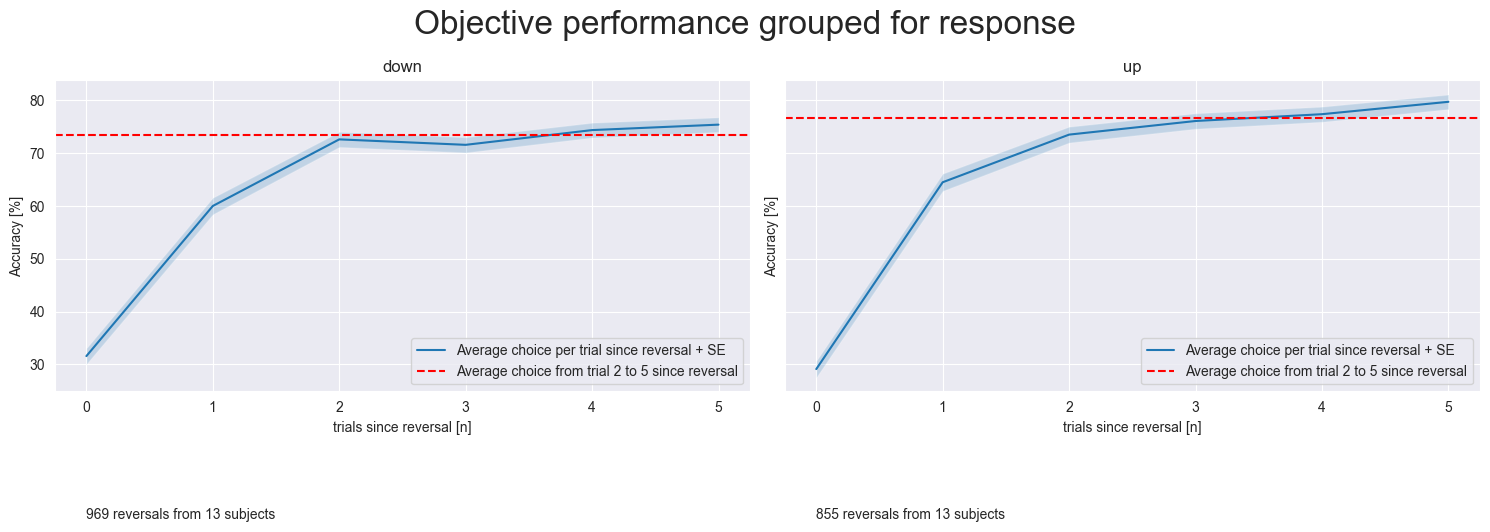

In [13]:
# Prepare the DataFrame by setting 'stimuli_type' as the index temporarily
df = all_reversals_dataframe

subject_counts = len(df['subject_id'].unique())

# Count the number of times both conditions were shown
group_counts = df['response'].value_counts()

# We are not using 'subject_id', so let's exclude it from our calculations
df = df.drop(columns=['subject_id'])
df = df.drop(columns=['stimuli_type'])

# Calculate the mean and standard deviation for each timepoint and stimuli_type
means = df.groupby(['response']).mean()
means_overall = means.iloc[:, 2:]
average_choice_after_reversal_total = means_overall.mean(axis=1).tolist()

stds = df.groupby(['response']).sem()

# Plotting
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15, 6), sharex=True, sharey=True) # Adjust based on the number of stimuli_types
axs = axs.flatten() # Flatten to iterate easily

fig.suptitle('Objective performance grouped for response', fontsize=24, y=0.982)

congruency_list = df['response'].unique()

congruency_types = means.index
for i, congruency_type in enumerate(congruency_types):
    # Timepoints are the column names converted to integers for x-axis values
    timepoints = list(range(plot_range[0], plot_range[1]))
    mean_values = means.loc[congruency_type]
    std_values = stds.loc[congruency_type]

    axs[i].plot(timepoints, mean_values, label='Average choice per trial since reversal + SE')
    axs[i].fill_between(timepoints, mean_values - std_values, mean_values + std_values, alpha=0.2)
    axs[i].axhline((average_choice_after_reversal_total[i]), color='r', linestyle='--', label='Average choice from trial 2 to 5 since reversal')
    #axs[i].plot(probability_dataframe_pivoted[i+1].dropna())
    axs[i].set_title(f'{congruency_list[i]}')
    axs[i].set_xlabel('trials since reversal [n]')
    axs[i].set_ylabel('Accuracy [%]')
    axs[i].text(0, 0.78, f'{group_counts[congruency_type]} reversals from {subject_counts} subjects', fontsize=10)
    axs[i].legend()
    axs[i].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'objective_performance_grouped_for_response.pdf'))
plt.show()

# Now plot subplots for the responses and congruency
To see whether giving one type of response interacted with congruency, also as a check

In [14]:
# Create new plots with different intervals that also contain the 50% trials
group_name_1 = 'congruency'
group_name_2 = 'response'
initial_columns = {0: 'stimuli_type', 1: 'subject_id', 2: group_name_2, 3: group_name_1}
# Append the plot range to the existing dictionary
mapping = initial_columns.copy()
mapping.update({k+4: v for k, v in enumerate(plot_range)})

dataframe = utils.analysis_functions.find_reversals_in_dataframe(combined_results_dataframe,
                                                                             unique_subject_ids, unique_stimuli_types,
                                                                             group_name_1, plot_range, mapping, group_name_2)
print(dataframe)

      subject_id  trial  stimuli_type  probability_condition  reversal  \
0        sub-005      8             1                     20     False   
1        sub-005     11             1                     20     False   
2        sub-005     12             1                     20     False   
3        sub-005     14             1                     20     False   
4        sub-005     15             1                     20     False   
...          ...    ...           ...                    ...       ...   
24843    sub-038    659             2                     20     False   
24844    sub-038    660             2                     20     False   
24845    sub-038    661             2                     20     False   
24846    sub-038    665             2                     20     False   
24847    sub-038    666             2                     20     False   

        congruency response  
0      incongruent       up  
1      incongruent       up  
2      incongruent   

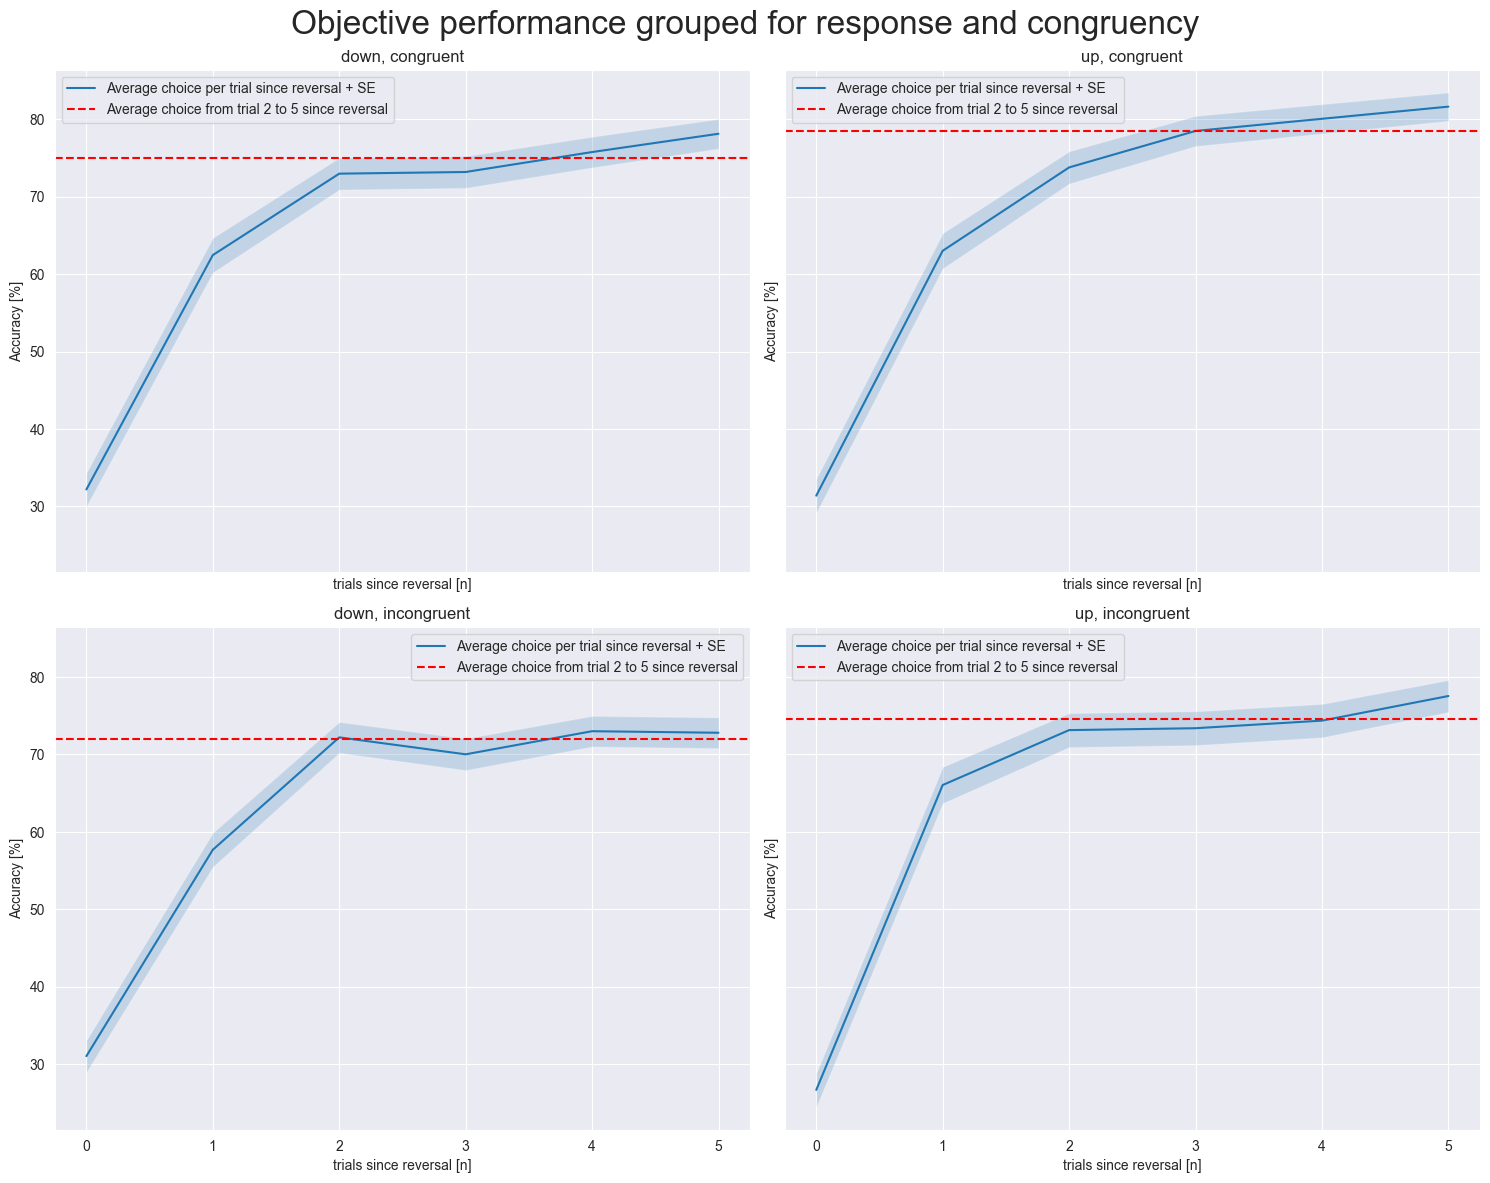

In [15]:
# Prepare the DataFrame by setting 'stimuli_type' as the index temporarily
df = dataframe

# We are not using 'subject_id', so let's exclude it from our calculations
df = df.drop(columns=['subject_id', 'stimuli_type'])

# Calculate the mean and standard deviation for each timepoint and stimuli_type
means = df.groupby(['congruency', 'response']).mean()
means_overall = means.iloc[:, 2:]
average_choice_after_reversal_total = means_overall.mean(axis=1).tolist()

stds = df.groupby(['congruency', 'response']).sem()

# Plotting
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(15, 12), sharex=True, sharey=True) # Adjust based on the number of stimuli_types
axs = axs.flatten() # Flatten to iterate easily

fig.suptitle('Objective performance grouped for response and congruency', fontsize=24, y=0.982)

congruency_list = df['congruency'].unique()
volatility_list = df['response'].unique()

congruency_types = means.index
for i, congruency_type in enumerate(congruency_types):
    if congruency_type != 'undefined':
        # Timepoints are the column names converted to integers for x-axis values
        timepoints = list(range(plot_range[0], plot_range[1]))
        mean_values = means.loc[congruency_type]
        std_values = stds.loc[congruency_type]

        axs[i].plot(timepoints, mean_values, label='Average choice per trial since reversal + SE')
        axs[i].fill_between(timepoints, mean_values - std_values, mean_values + std_values, alpha=0.2)
        axs[i].axhline((average_choice_after_reversal_total[i]), color='r', linestyle='--', label='Average choice from trial 2 to 5 since reversal')
        #axs[i].plot(probability_dataframe_pivoted[i+1].dropna())
        axs[i].set_title(f'{congruency_type[1]}, {congruency_type[0]}')
        axs[i].set_xlabel('trials since reversal [n]')
        axs[i].set_ylabel('Accuracy [%]')
        axs[i].legend()
        axs[i].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'objective_performance_grouped_for_response_and_congruency.pdf'))
plt.show()

# Objectively correct answers binned around a reversal
Starting 12 trials before the reversal and ending 4 after.

In [16]:
# Create new plots with different intervals that also contain the 50% trials
objectively_correct_answers_per_reversal_block = pd.DataFrame()
adjusted_plot_range = [plot_range[0] - plot_range[1] + 1, plot_range[1]]

all_reversals_dataframe = utils.analysis_functions.find_reversals_in_dataframe(combined_results_dataframe,
                                                                             unique_subject_ids, unique_stimuli_types,
                                                                             group_name, adjusted_plot_range, mapping)
print(all_reversals_dataframe)

      subject_id  trial  stimuli_type  probability_condition  reversal  \
0        sub-005      8             1                     20     False   
1        sub-005     11             1                     20     False   
2        sub-005     12             1                     20     False   
3        sub-005     14             1                     20     False   
4        sub-005     15             1                     20     False   
...          ...    ...           ...                    ...       ...   
24843    sub-038    659             2                     20     False   
24844    sub-038    660             2                     20     False   
24845    sub-038    661             2                     20     False   
24846    sub-038    665             2                     20     False   
24847    sub-038    666             2                     20     False   

      response  
0           up  
1           up  
2           up  
3         down  
4         down  
...      

# Subplots for incongruent and congruent reversals

In [17]:
# Create new plots with different intervals that also contain the 50% trials
mapping = {0: 'subject_id', 1: 'stimuli_type', 2: 'congruency', 3: 0, 4: 1, 5: 2, 6: 3, 7: 4, 8: 5, 9: 6}
group_name = 'congruency'
session_name = 'session'
unique_group_types = combined_results_dataframe[group_name].unique()


all_reversals_dataframe = utils.analysis_functions.find_reversals_in_dataframe(combined_results_dataframe,
                                                                             unique_subject_ids, unique_stimuli_types,
                                                                             group_name, plot_range, mapping, session_name)
print(all_reversals_dataframe)

      subject_id  trial  stimuli_type  probability_condition  reversal  \
0        sub-005      8             1                     20     False   
1        sub-005     11             1                     20     False   
2        sub-005     12             1                     20     False   
3        sub-005     14             1                     20     False   
4        sub-005     15             1                     20     False   
...          ...    ...           ...                    ...       ...   
24843    sub-038    659             2                     20     False   
24844    sub-038    660             2                     20     False   
24845    sub-038    661             2                     20     False   
24846    sub-038    665             2                     20     False   
24847    sub-038    666             2                     20     False   

        congruency     session  
0      incongruent  session-02  
1      incongruent  session-02  
2      incon

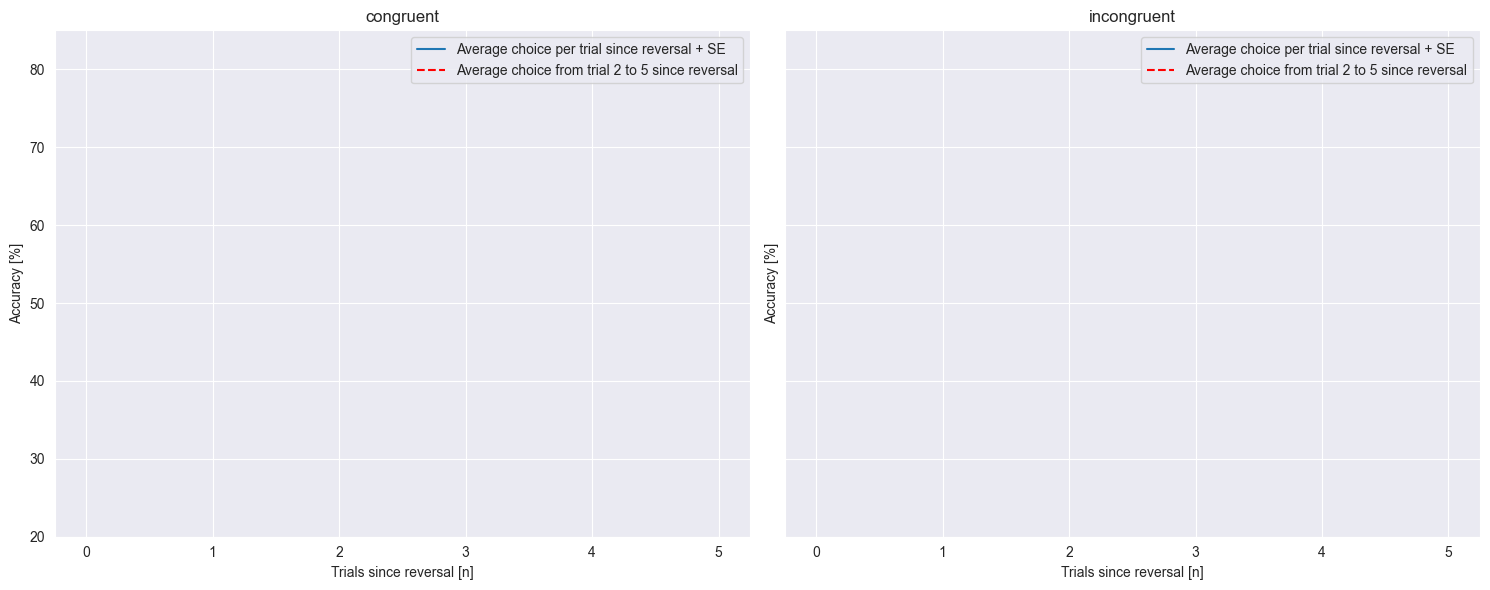

In [18]:
# Prepare the DataFrame by setting 'stimuli_type' as the index temporarily
df = all_reversals_dataframe.set_index('congruency')

subject_counts = len(df['subject_id'].unique())

# Count the number of times both conditions were shown
group_counts = df.index.value_counts()

# We are not using 'subject_id', so let's exclude it from our calculations
df = df.drop(columns=['subject_id'])
df = df.drop(columns=['stimuli_type'])
df = df.drop(columns=['session'])

# Calculate the mean and standard deviation for each timepoint and stimuli_type
means = df.groupby('congruency').mean()
means = means*100
means_overall = means.iloc[:, 2:]
average_choice_after_reversal_total = means_overall.mean(axis=1).tolist()
stds = df.groupby('congruency').sem()
stds = stds * 100

# Plotting
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15, 6), sharex=False, sharey=True) # Adjust based on the number of stimuli_types
axs = axs.flatten() # Flatten to iterate easily

#fig.suptitle('Objective performance grouped for congruency', fontsize=24, y=0.982)

congruency_list = all_reversals_dataframe['congruency'].unique()

congruency_types = means.index
for i, congruency_type in enumerate(congruency_types):
    if congruency_type != 'undefined':
        # Timepoints are the column names converted to integers for x-axis values
        timepoints = list(range(plot_range[0], plot_range[1]))
        mean_values = means.loc[congruency_type]
        std_values = stds.loc[congruency_type]

        axs[i].plot(timepoints, mean_values, label='Average choice per trial since reversal + SE')
        axs[i].fill_between(timepoints, mean_values - std_values, mean_values + std_values, alpha=0.2)
        axs[i].axhline((average_choice_after_reversal_total[i]), color='r', linestyle='--', label='Average choice from trial 2 to 5 since reversal')
        #axs[i].plot(probability_dataframe_pivoted[i+1].dropna())
        axs[i].set_title(congruency_type)
        axs[i].set_xlabel('Trials since reversal [n]')
        axs[i].set_ylabel('Accuracy [%]')
        #axs[i].text(-0.2, 72.5, f'{group_counts[congruency_type]} reversals from {subject_counts} subjects', fontsize=10)
        axs[i].legend()
        axs[i].grid(True)

plt.ylim(20, 85)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'objective_performance_grouped_for_congruency.pdf'))
plt.show()

## Comparing congruency direction

   subject_id     session  congruent  incongruent
0     sub-005  session-02  82.636656    79.054054
1     sub-005  session-03  82.903226    78.644068
2     sub-005  session-04  73.026316    83.441558
3     sub-010  session-02  78.947368    74.385965
4     sub-010  session-03  80.634921    82.711864
5     sub-010  session-04  84.967320    83.720930
6     sub-014  session-02  66.666667    68.135593
7     sub-014  session-03  70.469799    67.419355
8     sub-014  session-04  79.742765    80.743243
9     sub-015  session-02  77.777778    73.208723
10    sub-015  session-03  76.842105    71.207430
11    sub-015  session-04  83.177570    77.003484
12    sub-016  session-02  78.417266    74.603175
13    sub-016  session-03  76.811594    75.477707
14    sub-020  session-02  88.405797    63.665595
15    sub-020  session-03  80.000000    67.492260
16    sub-020  session-04  71.844660    69.852941
17    sub-022  session-02  79.861111    76.086957
18    sub-022  session-03  74.912892    76.012461


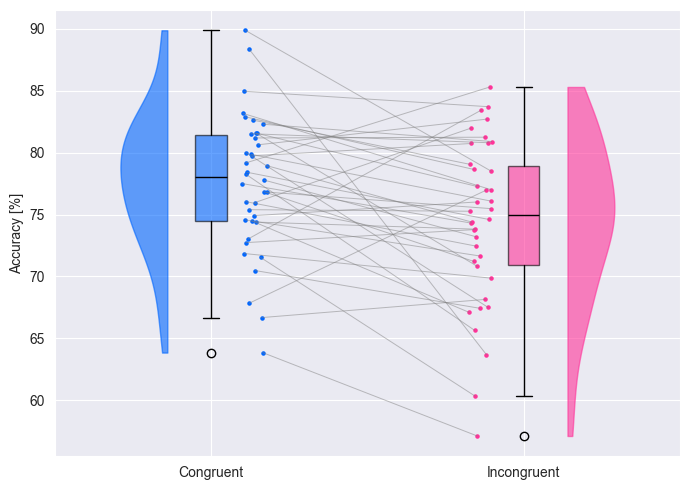

In [19]:
# Comparing overall congruency performance difference
# Single-pass aggregation & reshape
combined_results_pivoted = combined_results_dataframe[combined_results_dataframe['trials_since_reversal'] != 0]
combined_results_pivoted = (
    combined_results_pivoted
    .pivot_table(
        index=['subject_id', 'session'],
        columns='congruency',
        values='objectively_correct_boolean',
        aggfunc='mean'
    )
    .reset_index()
)
combined_results_pivoted = combined_results_pivoted.rename_axis(None, axis=1)
print(combined_results_pivoted)

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud_2_groups(
    combined_results_pivoted,
    column_1='congruent',
    column_2='incongruent',
    labels=['Congruent', 'Incongruent'],
    output_dir=output_dir,
    ylabel_name='Accuracy [%]',
    plot_name='all_trials_objective_performance_congruency'
)

In [20]:
'''
# Comparing overall congruency performance difference
# Single-pass aggregation & reshape
combined_results_pivoted = combined_results_dataframe[combined_results_dataframe['trials_since_reversal'] != 0]
combined_results_pivoted = (
    combined_results_pivoted
    .pivot_table(
        index=['subject_id', 'session'],
        columns=['response','valence','volatility'],
        values='objectively_correct_boolean',
        aggfunc='mean'
    )
    .reset_index()
)
combined_results_pivoted = combined_results_pivoted.rename_axis(None, axis=1)
print(combined_results_pivoted)

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud_8_groups(
    combined_results_pivoted,
    columns=['response','valence','volatility'],
    output_dir=output_dir,
    ylabel_name='Accuracy [%]',
    plot_name='all_trials_objective_performance_congruency'
)
'''

"\n# Comparing overall congruency performance difference\n# Single-pass aggregation & reshape\ncombined_results_pivoted = combined_results_dataframe[combined_results_dataframe['trials_since_reversal'] != 0]\ncombined_results_pivoted = (\n    combined_results_pivoted\n    .pivot_table(\n        index=['subject_id', 'session'],\n        columns=['response','valence','volatility'],\n        values='objectively_correct_boolean',\n        aggfunc='mean'\n    )\n    .reset_index()\n)\ncombined_results_pivoted = combined_results_pivoted.rename_axis(None, axis=1)\nprint(combined_results_pivoted)\n\n# Plot the two groups using a raincloud plot\nutils.plotting_functions.paired_raincloud_8_groups(\n    combined_results_pivoted,\n    columns=['response','valence','volatility'],\n    output_dir=output_dir,\n    ylabel_name='Accuracy [%]',\n    plot_name='all_trials_objective_performance_congruency'\n)\n"

In [21]:
# Create new plots with different intervals that also contain the 50% trials
plot_range = [-6, 6]
static_mapping = {
    0: 'subject_id',
    1: 'stimuli_type',
    2: 'congruency',
}

# pick the first and last values you want in the numeric run
start_value = plot_range[0]
end_value   = plot_range[1]

# build the list of values
values = list(range(start_value, end_value + 1))

# compute where the keys should start (one past your highest static key)
start_key = max(static_mapping) + 1

# zip them together into a dict
numeric_mapping = dict(zip(range(start_key, start_key + len(values)), values))

# merge
mapping = {**static_mapping, **numeric_mapping}

print(mapping)

group_name = 'congruency'
session_name = 'session'
unique_group_types = combined_results_dataframe[group_name].unique()


all_reversals_dataframe = utils.analysis_functions.find_reversals_in_dataframe(combined_results_dataframe,
                                                                             unique_subject_ids, unique_stimuli_types,
                                                                             group_name, plot_range, mapping, session_name)
print(all_reversals_dataframe)

{0: 'subject_id', 1: 'stimuli_type', 2: 'congruency', 3: -6, 4: -5, 5: -4, 6: -3, 7: -2, 8: -1, 9: 0, 10: 1, 11: 2, 12: 3, 13: 4, 14: 5, 15: 6}
      subject_id  trial  stimuli_type  probability_condition  reversal  \
0        sub-005      8             1                     20     False   
1        sub-005     11             1                     20     False   
2        sub-005     12             1                     20     False   
3        sub-005     14             1                     20     False   
4        sub-005     15             1                     20     False   
...          ...    ...           ...                    ...       ...   
24843    sub-038    659             2                     20     False   
24844    sub-038    660             2                     20     False   
24845    sub-038    661             2                     20     False   
24846    sub-038    665             2                     20     False   
24847    sub-038    666             2     

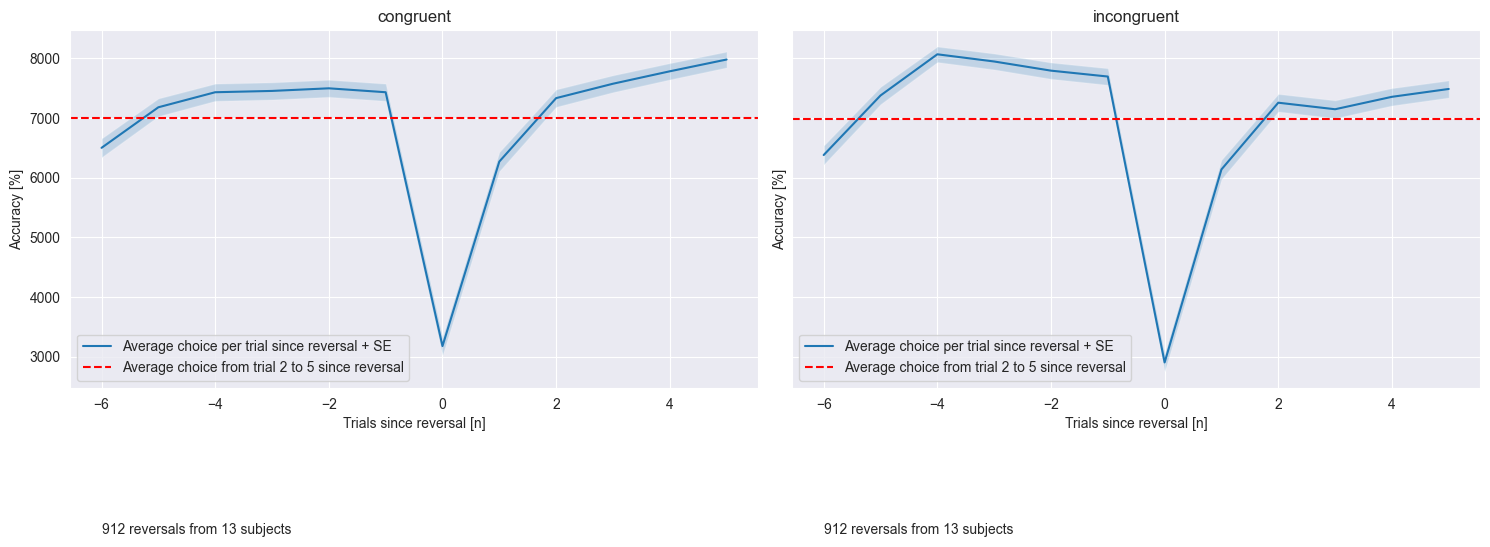

In [22]:
# Prepare the DataFrame by setting 'stimuli_type' as the index temporarily
df = all_reversals_dataframe.set_index('congruency')

subject_counts = len(df['subject_id'].unique())

# Count the number of times both conditions were shown
group_counts = df.index.value_counts()

# We are not using 'subject_id', so let's exclude it from our calculations
df = df.drop(columns=['subject_id'])
df = df.drop(columns=['stimuli_type'])
df = df.drop(columns=['session'])

# Calculate the mean and standard deviation for each timepoint and stimuli_type
means = df.groupby('congruency').mean()
means = means*100
means_overall = means.iloc[:, 2:]
average_choice_after_reversal_total = means_overall.mean(axis=1).tolist()
stds = df.groupby('congruency').sem()
stds = stds * 100

# Plotting
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15, 6), sharex=False, sharey=True) # Adjust based on the number of stimuli_types
axs = axs.flatten() # Flatten to iterate easily

#fig.suptitle('Objective performance grouped for congruency', fontsize=24, y=0.982)

congruency_list = all_reversals_dataframe['congruency'].unique()

congruency_types = means.index
for i, congruency_type in enumerate(congruency_types):
    if congruency_type != 'undefined':
        # Timepoints are the column names converted to integers for x-axis values
        timepoints = list(range(plot_range[0], plot_range[1]))
        mean_values = means.loc[congruency_type]
        std_values = stds.loc[congruency_type]

        axs[i].plot(timepoints, mean_values, label='Average choice per trial since reversal + SE')
        axs[i].fill_between(timepoints, mean_values - std_values, mean_values + std_values, alpha=0.2)
        axs[i].axhline((average_choice_after_reversal_total[i]), color='r', linestyle='--', label='Average choice from trial 2 to 5 since reversal')
        #axs[i].plot(probability_dataframe_pivoted[i+1].dropna())
        axs[i].set_title(congruency_type)
        axs[i].set_xlabel('Trials since reversal [n]')
        axs[i].set_ylabel('Accuracy [%]')
        axs[i].text(-6, 30, f'{group_counts[congruency_type]} reversals from {subject_counts} subjects', fontsize=10)
        axs[i].legend()
        axs[i].grid(True)

#plt.ylim(20, 85)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'objective_performance_grouped_for_congruency_before_and_after.pdf'))
plt.show()
plot_range = [0, 6]

# Chance of a forward response around reversal
Here, we plot the chance of a forward response around a reversal, hoping to capture a flip in the reversal for the four categories:
- happy incongruent > congruent
- angry incongruent > congruent
- happy congruent > incongruent
- angry congruent > incongruent

In [23]:
# First create a new dataframe with the 
adjusted_plot_range = [plot_range[0] - plot_range[1], plot_range[1] - 1]
dataframe = utils.analysis_functions.bin_responses_for_congruency(combined_results_dataframe, adjusted_plot_range, 'stimuli_type')

# Map transitions to congruency
to_flip = {
    'happy_congruent_to_incongruent',
    'happy_incongruent_to_congruent'
}

# build a boolean mask for rows to flip
mask = dataframe['emotional_valence_and_transition'].isin(to_flip)

# apply the flip
dataframe.loc[mask, 'response_int'] = 100 - dataframe.loc[mask, 'response_int']

# define your mapping
mapping = {
    'angry_congruent_to_incongruent':    'congruent_to_incongruent',
    'happy_incongruent_to_congruent':    'incongruent_to_congruent',
    'angry_incongruent_to_congruent':    'incongruent_to_congruent',
    'happy_congruent_to_incongruent':    'congruent_to_incongruent',
    'angry_no_transition':               'no_transition',
    'happy_no_transition':               'no_transition',
}

# create new column
dataframe['transitions_combined'] = (
    dataframe['emotional_valence_and_transition']
     .map(mapping)
     .fillna('unknown')   # optional: catch any unexpected values
)

print(dataframe[['trials_around_reversal','stimuli_type','congruency']])

[0, 30, 62, 68, 76, 82, 90, 96, 106, 138, 166, 174, 183, 189, 195, 205, 213, 242, 270, 276, 286, 293, 303, 311, 321, 327, 357, 389, 395, 403, 409, 417, 423, 433, 465, 493, 501, 511, 517, 523, 532, 540, 570, 598, 604, 614, 622, 632, 640, 650, 686, 716, 722, 732, 742, 749, 759, 765, 797, 829, 837, 847, 853, 861, 871, 879, 907, 935, 945, 951, 957, 965, 973, 979, 985, 1014, 1044, 1050, 1060, 1070, 1078, 1088, 1094, 1125, 1157, 1164, 1174, 1180, 1188, 1198, 1206, 1233, 1261, 1271, 1277, 1283, 1291, 1299, 1305, 1311, 1321, 1331, 1339, 1347, 1355, 1361, 1389, 1419, 1429, 1439, 1449, 1457, 1463, 1471, 1501, 1533, 1539, 1545, 1553, 1563, 1569, 1575, 1603, 1635, 1641, 1651, 1661, 1669, 1677, 1685, 1691, 1719, 1749, 1759, 1769, 1779, 1787, 1793, 1801, 1831, 1863, 1869, 1875, 1883, 1893, 1899, 1905, 1933, 1965, 1971, 1981, 1987, 1997, 2003, 2011, 2021, 2053, 2083, 2091, 2099, 2105, 2115, 2122, 2130, 2160, 2188, 2196, 2202, 2212, 2222, 2228, 2234, 2266, 2294, 2300, 2310, 2315, 2325, 2331, 2339, 234

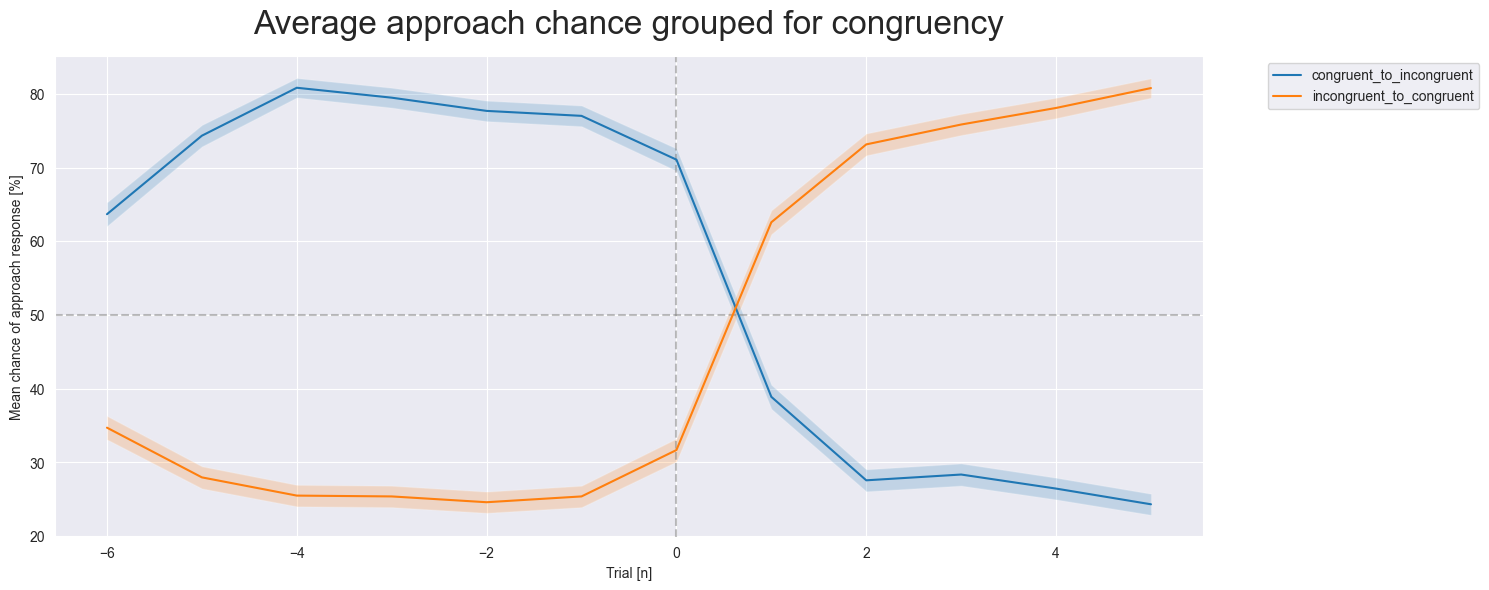

In [24]:
# Group the data
grouped_dataframe = dataframe.groupby(['trials_around_reversal', 'transitions_combined'])['response_int'].agg(['mean', 'sem']).reset_index()

# Plotting with Matplotlib
plt.figure(figsize=(15, 6))

# Define the unique groups for 'emotional_valence' and 'transition'
transitions = grouped_dataframe['transitions_combined'].unique()
transitions = [s for s in transitions if 'no_transition' not in s]

# Plot each group
plt.axhline(50, color='grey', linestyle='dashed', alpha=0.5)
plt.axvline(0, color='grey', linestyle='dashed', alpha=0.5)
for transition in transitions:
    subset = grouped_dataframe[grouped_dataframe['transitions_combined'] == transition]
    current_transition = subset['transitions_combined'].unique()
    if not subset.empty:
        plt.plot(subset['trials_around_reversal'], subset['mean'], label=f'{transition}')
        plt.fill_between(subset['trials_around_reversal'], subset['mean'] - subset['sem'], subset['mean'] + subset['sem'], alpha=0.2)

# Customize the plot
plt.xlabel('Trial [n]')
plt.ylabel('Approach chance [%]')
plt.title('Average approach chance grouped for congruency', fontsize=24, y=1.03)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()

plt.savefig(os.path.join(output_dir, 'average_approach_chance_grouped_for_congruency.pdf'))
# Show the plot
plt.show()

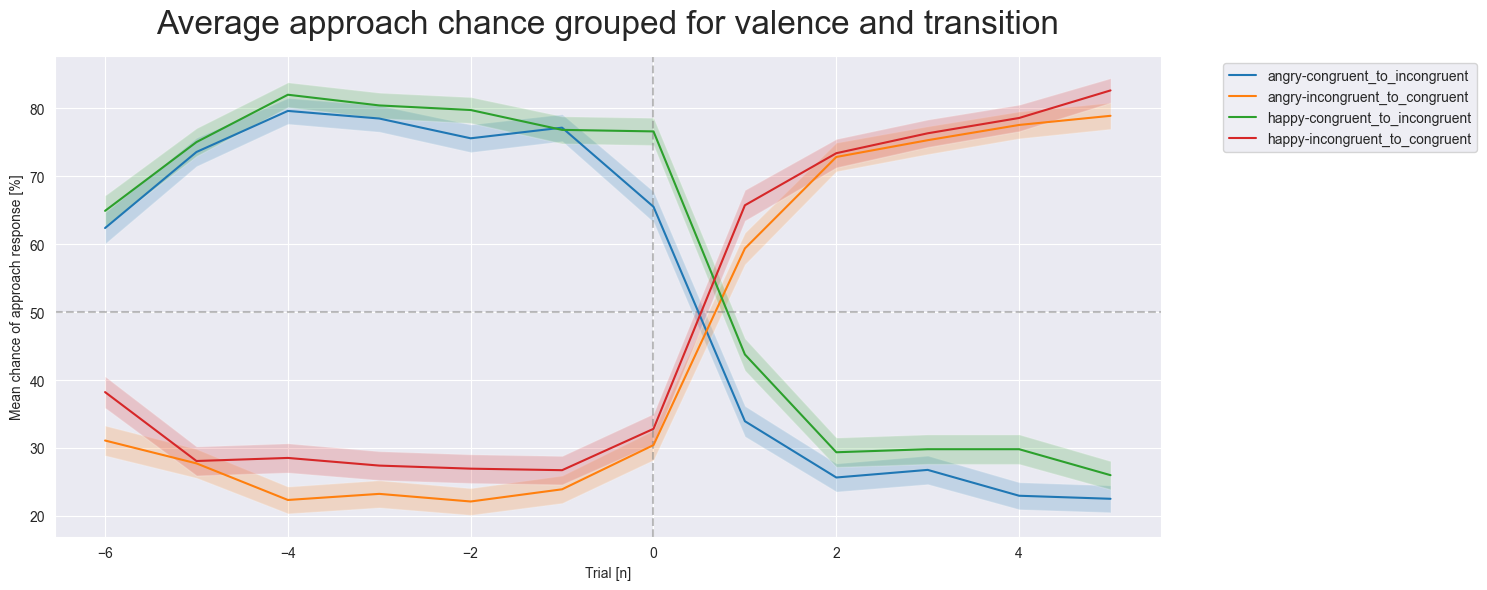

In [25]:
# Group the data
grouped_dataframe = dataframe.groupby(['trials_around_reversal', 'emotional_valence', 'transition'])['response_int'].agg(['mean', 'sem']).reset_index()

# Plotting with Matplotlib
plt.figure(figsize=(15, 6))

# Define the unique groups for 'emotional_valence' and 'transition'
emotional_valences = grouped_dataframe['emotional_valence'].unique()
transitions = grouped_dataframe['transition'].unique()
transitions = transitions[transitions != 'no_transition']

# Plot each group
plt.axhline(50, color='grey', linestyle='dashed', alpha=0.5)
plt.axvline(0, color='grey', linestyle='dashed', alpha=0.5)
for valence in emotional_valences:
    for transition in transitions:
        subset = grouped_dataframe[(grouped_dataframe['emotional_valence'] == valence) & (grouped_dataframe['transition'] == transition)]
        current_emotion = subset['emotional_valence'].unique()
        current_transition = subset['transition'].unique()
        if not subset.empty:
            plt.plot(subset['trials_around_reversal'], subset['mean'], label=f'{valence}-{transition}')
            plt.fill_between(subset['trials_around_reversal'], subset['mean'] - subset['sem'], subset['mean'] + subset['sem'], alpha=0.2)

# Customize the plot
plt.xlabel('Trial [n]')
plt.ylabel('Approach chance [%]')
plt.title('Average approach chance grouped for valence and transition', fontsize=24, y=1.03)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()

plt.savefig(os.path.join(output_dir, 'average_approach_chance_grouped_for_valence_and_transition.pdf'))
# Show the plot
plt.show()

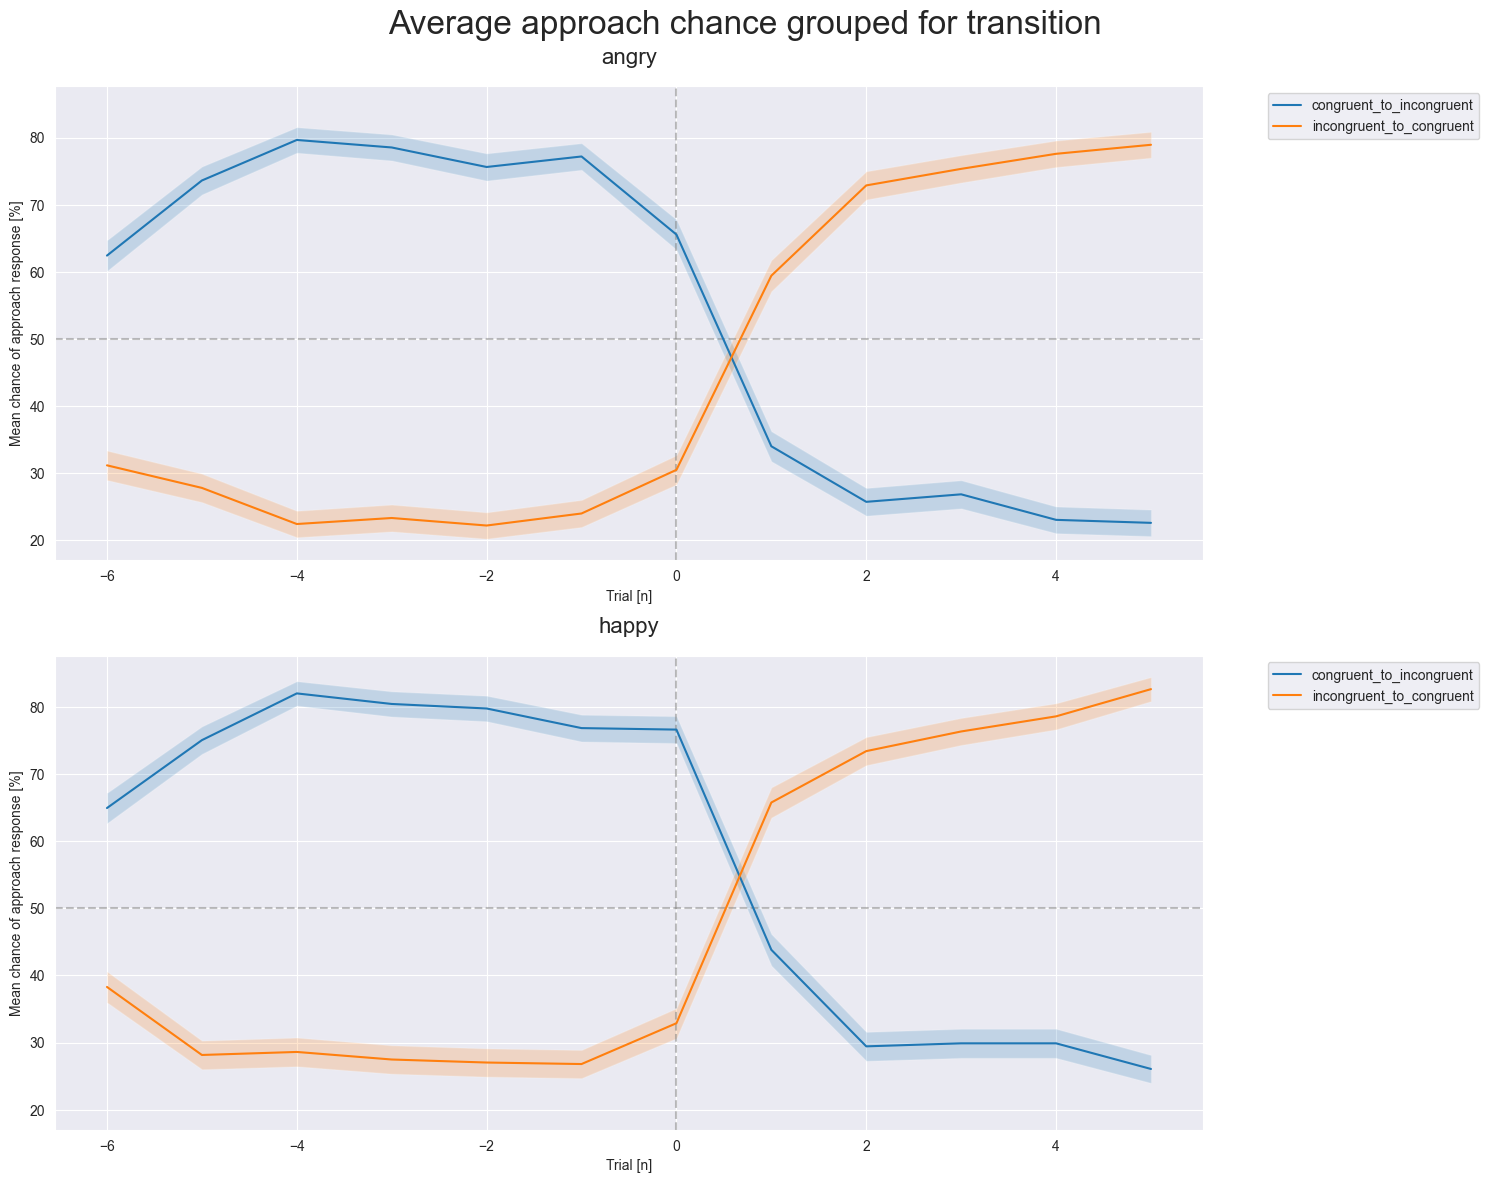

In [26]:
# Plotting with Matplotlib
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(15, 12), sharey=True)

fig.suptitle('Average approach chance grouped for transition', fontsize=24, y=0.982)

# Plot each group
for valence_index, valence_value in enumerate(emotional_valences):
    axes[valence_index].axhline(50, color='grey', linestyle='dashed', alpha=0.5)
    axes[valence_index].axvline(0, color='grey', linestyle='dashed', alpha=0.5)
    for transition in transitions:
        subset = grouped_dataframe[(grouped_dataframe['emotional_valence'] == valence_value) & (grouped_dataframe['transition'] == transition)]
        current_emotion = subset['emotional_valence'].unique()
        current_transition = subset['transition'].unique()
        if not subset.empty:
            axes[valence_index].plot(subset['trials_around_reversal'], subset['mean'], label=f'{transition}')
            axes[valence_index].fill_between(subset['trials_around_reversal'], subset['mean'] - subset['sem'], subset['mean'] + subset['sem'], alpha=0.2)

    # Customize the plot
    axes[valence_index].set_xlabel('Trial [n]')
    axes[valence_index].set_ylabel('Approach chance [%]')
    axes[valence_index].set_title(valence_value, fontsize=16, y=1.03)
    axes[valence_index].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.grid(True)
plt.tight_layout()

plt.savefig(os.path.join(output_dir, 'average_approach_chance_separated_by_valence_and_grouped_for_transition.pdf'))
# Show the plot
plt.show()

In [27]:
# Add a plot where the two emotions are combined and one transition is inverted to compare them bettter

# Plot volatile and stable blocks separately
Fix this, clearly broken

In [28]:
'''pd.set_option('display.max_rows', None)
# Check if a block is volatile or stable
dataframe = combined_results_dataframe[combined_results_dataframe['probability_condition'] != 50]
dataframe = utils.analysis_functions.check_volatility(dataframe)
dataframe = dataframe.sort_values(by=['subject_id', 'session', 'stimuli_type', 'trial'], ascending=[True, True, True, True])
print(dataframe[['subject_id', 'session', 'trial', 'stimuli_type', 'probability_condition', 'volatility']])'''
dataframe = combined_results_dataframe
print(combined_results_dataframe)

       trial  emotional_cue_time response objectively_correct  \
0          8        1.741947e+09       up               False   
0          9        1.741947e+09       up                True   
1         10        1.741947e+09     down               False   
1         11        1.741947e+09       up               False   
2         12        1.741947e+09       up               False   
...      ...                 ...      ...                 ...   
12537    663        1.761046e+09       up                True   
12538    664        1.761046e+09       up                True   
12538    665        1.761046e+09     down                True   
12539    666        1.761046e+09       up               False   
12539    667        1.761046e+09       up                True   

      subjectively_correct  response_time   RT_s  feedback_time  stimuli_type  \
0                    False   1.741947e+09  0.635   1.741947e+09             1   
0                    False   1.741947e+09  0.832   1.7419

In [29]:
# Create new plots with different intervals that also contain the 50% trials
mapping = {0: 'subject_id', 1: 'stimuli_type', 2: 'volatility', 3: 0, 4: 1, 5: 2, 6: 3, 7: 4, 8: 5}
group_name = 'volatility'
session_name = 'session'
unique_group_types = combined_results_dataframe[group_name].unique()
pd.set_option('display.max_rows', 20)
dataframe_with_session = utils.analysis_functions.find_reversals_in_dataframe(combined_results_dataframe,
                                                                unique_subject_ids, unique_stimuli_types,
                                                                group_name, plot_range, mapping, session_name)

print(dataframe_with_session)

dataframe_without_session = utils.analysis_functions.find_reversals_in_dataframe(combined_results_dataframe,
                                                                unique_subject_ids, unique_stimuli_types,
                                                                group_name, plot_range, mapping)

print(dataframe_without_session)

      subject_id  trial  stimuli_type  probability_condition  reversal  \
0        sub-005      8             1                     20     False   
1        sub-005     11             1                     20     False   
2        sub-005     12             1                     20     False   
3        sub-005     14             1                     20     False   
4        sub-005     15             1                     20     False   
...          ...    ...           ...                    ...       ...   
24843    sub-038    659             2                     20     False   
24844    sub-038    660             2                     20     False   
24845    sub-038    661             2                     20     False   
24846    sub-038    665             2                     20     False   
24847    sub-038    666             2                     20     False   

      volatility     session  
0       volatile  session-02  
1       volatile  session-02  
2       volatile  

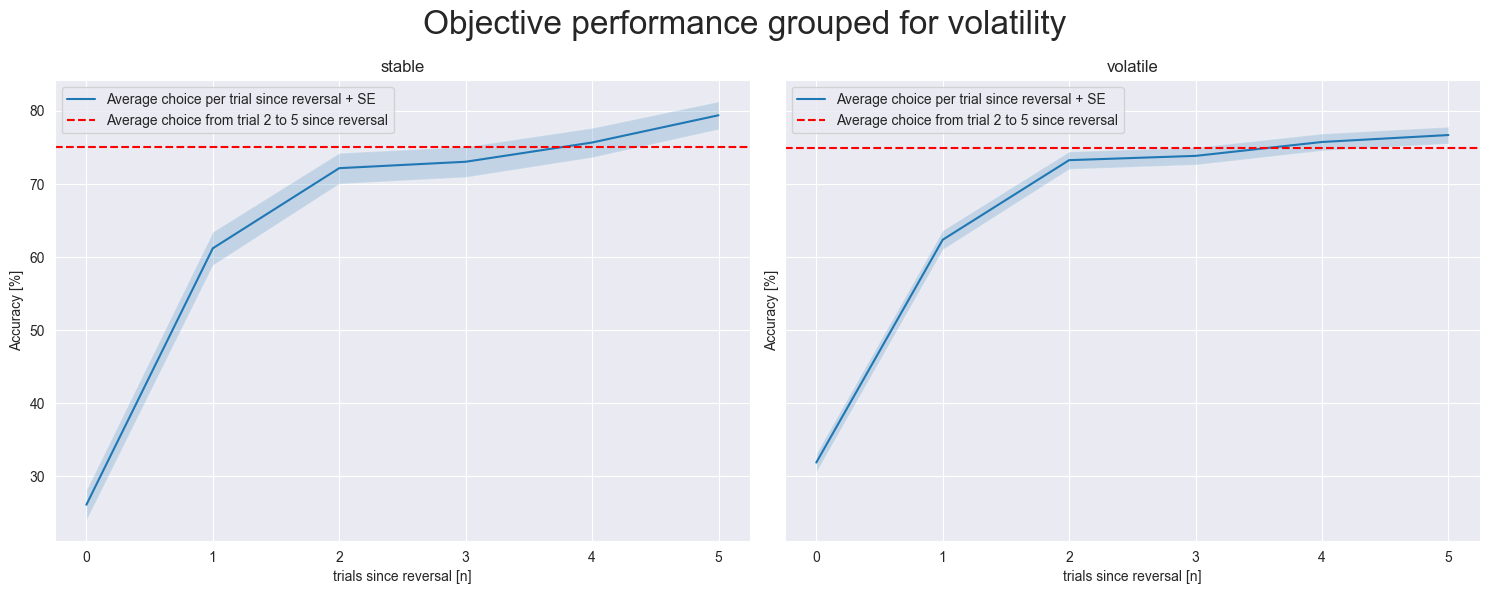

In [30]:
# Prepare the DataFrame by setting 'stimuli_type' as the index temporarily
df = dataframe_without_session.set_index('volatility')

subject_counts = len(df['subject_id'].unique())

# Count the number of times both conditions were shown
group_counts = df.index.value_counts()

# We are not using 'subject_id', so let's exclude it from our calculations
df = df.drop(columns=['subject_id'])
df = df.drop(columns=['stimuli_type'])

# Calculate the mean and standard deviation for each timepoint and stimuli_type
means = df.groupby('volatility').mean()
means_overall = means.iloc[:, 2:]
average_choice_after_reversal_total = means_overall.mean(axis=1).tolist()
stds = df.groupby('volatility').sem()

# Plotting
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15, 6), sharex=False, sharey=True) # Adjust based on the number of stimuli_types
axs = axs.flatten() # Flatten to iterate easily

fig.suptitle('Objective performance grouped for volatility', fontsize=24, y=0.982)

congruency_list = dataframe_without_session['volatility'].unique()

congruency_types = means.index
for i, congruency_type in enumerate(congruency_types):
    # Timepoints are the column names converted to integers for x-axis values
    timepoints = list(range(plot_range[0], plot_range[1]))
    mean_values = means.loc[congruency_type]
    std_values = stds.loc[congruency_type]

    axs[i].plot(timepoints, mean_values, label='Average choice per trial since reversal + SE')
    axs[i].fill_between(timepoints, mean_values - std_values, mean_values + std_values, alpha=0.2)
    axs[i].axhline((average_choice_after_reversal_total[i]), color='r', linestyle='--', label='Average choice from trial 2 to 5 since reversal')
    #axs[i].plot(probability_dataframe_pivoted[i+1].dropna())
    axs[i].set_title(congruency_type)
    axs[i].set_xlabel('trials since reversal [n]')
    axs[i].set_ylabel('Accuracy [%]')
    #axs[i].text(0, 0.75, f'{group_counts[congruency_type]} reversals from {subject_counts} subjects', fontsize=10)
    axs[i].legend()
    axs[i].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'objective_performance_grouped_for_volatility.pdf'))
plt.show()

   subject_id     session     stable   volatile
0     sub-005  session-02  84.365782  66.561514
1     sub-005  session-03  77.971014  74.193548
2     sub-005  session-04  78.779070  69.303797
3     sub-010  session-02  73.391813  74.760383
4     sub-010  session-03  79.351032  77.115987
..        ...         ...        ...        ...
33    sub-037  session-03  72.832370  70.261438
34    sub-037  session-04  73.529412  66.134185
35    sub-038  session-02  79.360465  63.291139
36    sub-038  session-03  85.673352  71.335505
37    sub-038  session-04  82.058824  68.670886

[38 rows x 4 columns]


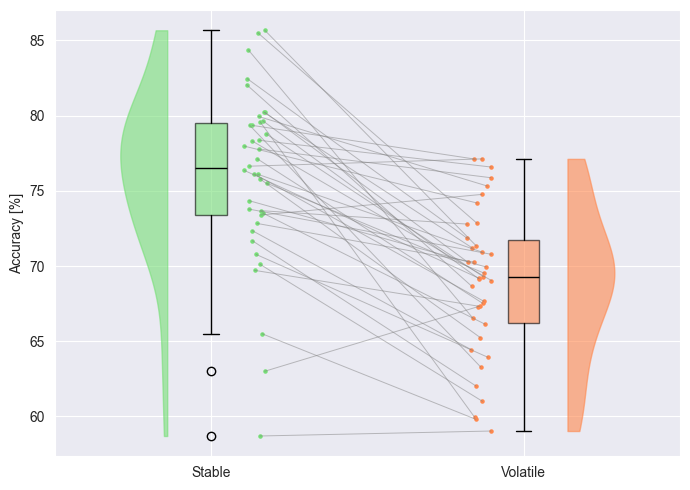

In [31]:
# Comparing overall congruency performance difference
# Single-pass aggregation & reshape
combined_results_pivoted = (
    combined_results_dataframe
    .pivot_table(
        index=['subject_id', 'session'],
        columns='volatility',
        values='objectively_correct_boolean',
        aggfunc='mean'
    )
    .reset_index()
)
combined_results_pivoted = combined_results_pivoted.rename_axis(None, axis=1)
print(combined_results_pivoted)

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud_2_groups(
    combined_results_pivoted,
    column_1='stable',
    column_2='volatile',
    labels=['Stable', 'Volatile'],
    output_dir=output_dir,
    ylabel_name='Accuracy [%]',
    plot_name='all_trials_objective_performance_volatility',
    colours=['#77DF77', '#FF884D']
)

   subject_id     session  congruent_stable  congruent_volatile  \
0     sub-005  session-02         87.500000           66.037736   
1     sub-005  session-03         75.151515           81.286550   
2     sub-005  session-04         70.512821           68.023256   
3     sub-010  session-02         75.000000           76.571429   
4     sub-010  session-03         78.846154           75.409836   
..        ...         ...               ...                 ...   
33    sub-037  session-03         75.722543           71.641791   
34    sub-037  session-04         74.390244           64.804469   
35    sub-038  session-02         82.386364           69.852941   
36    sub-038  session-03         90.285714           77.205882   
37    sub-038  session-04         83.734940           72.777778   

    incongruent_stable  incongruent_volatile  
0            80.981595             67.088608  
1            80.555556             65.467626  
2            85.638298             70.833333  
3      

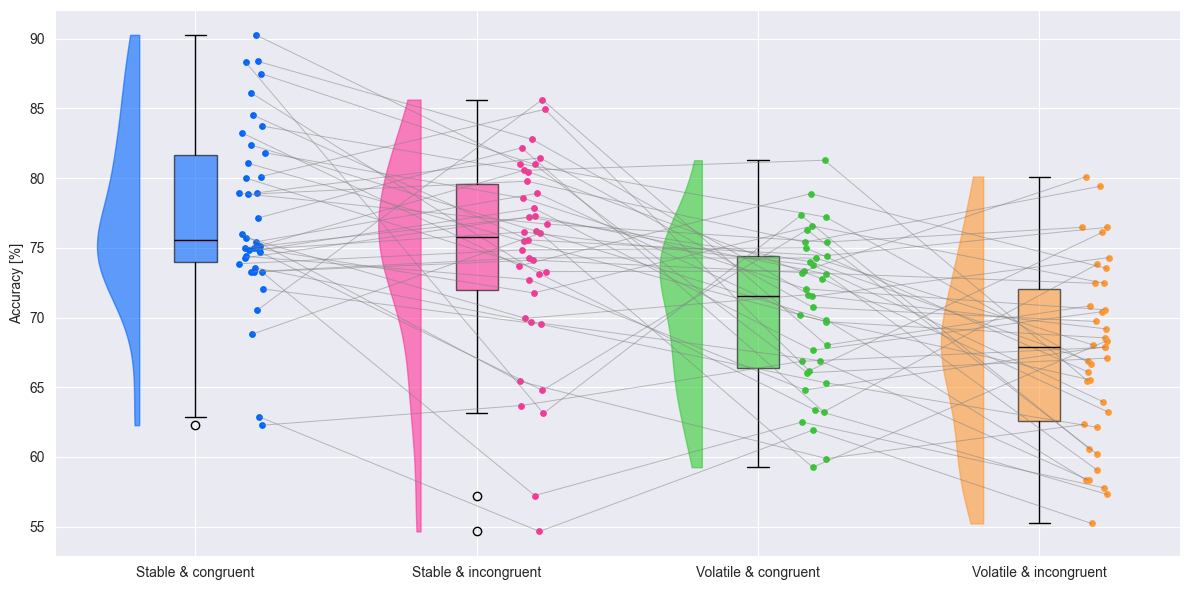

In [32]:
# Comparing overall congruency and volatility performance interaction
# Single-pass aggregation & reshape
combined_results_pivoted = (
    combined_results_dataframe
    .pivot_table(
        index=['subject_id', 'session'],
        columns=['congruency','volatility'],
        values='objectively_correct_boolean',
        aggfunc='mean'
    )
    .reset_index()
)
combined_results_pivoted.columns = [
    f"{a}_{b}" if b else a
    for a, b in combined_results_pivoted.columns
]
print(combined_results_pivoted)

# Plot the four groups using a raincloud plot
utils.plotting_functions.paired_raincloud_4_groups(
    combined_results_pivoted,
    columns=['congruent_stable','incongruent_stable','congruent_volatile','incongruent_volatile'],
    labels=['Stable & congruent','Stable & incongruent','Volatile & congruent','Volatile & incongruent'],
    output_dir=output_dir,
    ylabel_name='Accuracy [%]',
    plot_name='all_trials_objective_performance_congruency_volatility'
)

   subject_id     session   angry_-1    angry_1   happy_-1    happy_1
0     sub-005  session-02  62.025316  59.493671  72.500000  72.151899
1     sub-005  session-03  75.362319  79.069767  83.529412  55.714286
2     sub-005  session-04  72.222222  59.302326  76.744186  69.444444
3     sub-010  session-02  71.428571  80.459770  72.727273  73.529412
4     sub-010  session-03  77.941176  75.824176  75.000000  80.882353
..        ...         ...        ...        ...        ...        ...
33    sub-037  session-03  73.255814  71.212121  72.058824  65.116279
34    sub-037  session-04  65.671642  66.666667  62.921348  70.149254
35    sub-038  session-02  66.666667  66.176471  73.529412  50.000000
36    sub-038  session-03  70.588235  70.588235  83.823529  62.790698
37    sub-038  session-04  70.588235  73.333333  72.222222  55.882353

[38 rows x 6 columns]
plotting is turned off


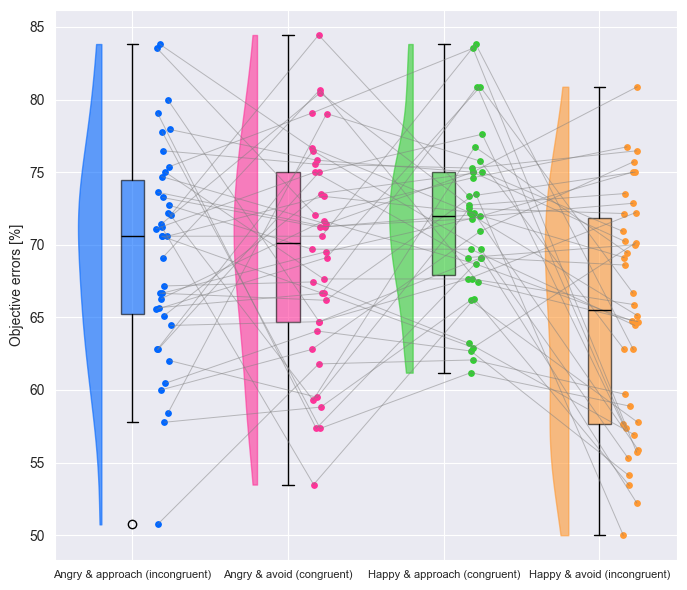

In [33]:
# Comparing overall congruency and volatility performance interaction
# Single-pass aggregation & reshape
combined_results_pivoted = combined_results_dataframe[combined_results_dataframe['volatility'] == 'volatile']
combined_results_pivoted = (
    combined_results_pivoted
    .pivot_table(
        index=['subject_id', 'session'],
        columns=['valence','correct_response_boolean'],
        values='objectively_correct_boolean',
        aggfunc='mean'
    )
    .reset_index()
)
combined_results_pivoted.columns = [
    f"{a}_{b}" if b else a
    for a, b in combined_results_pivoted.columns
]
print(combined_results_pivoted)

# Plot the four groups using a raincloud plot
utils.plotting_functions.paired_raincloud_4_groups(
    combined_results_pivoted,
    columns=['angry_-1','angry_1','happy_-1','happy_1'],
    labels=['Angry & approach (incongruent)','Angry & avoid (congruent)','Happy & approach (congruent)','Happy & avoid (incongruent)'],
    output_dir=output_dir,
    ylabel_name='Objective errors [%]',
    plot_name='all_trials_accuracy_volatile',
    plot_title='Errors correct response volatile',
    plot_full_width=False
)

   subject_id     session   angry_-1    angry_1   happy_-1    happy_1
0     sub-005  session-02  82.716049  85.227273  89.772727  79.268293
1     sub-005  session-03  83.333333  73.809524  76.543210  77.777778
2     sub-005  session-04  85.106383  70.512821  70.512821  86.170213
3     sub-010  session-02  63.953488  74.418605  75.581395  79.761905
4     sub-010  session-03  80.219780  78.205128  79.487179  79.347826
..        ...         ...        ...        ...        ...        ...
33    sub-037  session-03  74.418605  74.712644  76.744186  65.517241
34    sub-037  session-04  77.272727  78.313253  70.370370  68.181818
35    sub-038  session-02  80.952381  71.590909  93.181818  71.428571
36    sub-038  session-03  81.609195  88.505747  92.045455  80.459770
37    sub-038  session-04  85.057471  77.108434  90.361446  75.862069

[38 rows x 6 columns]
plotting is turned off


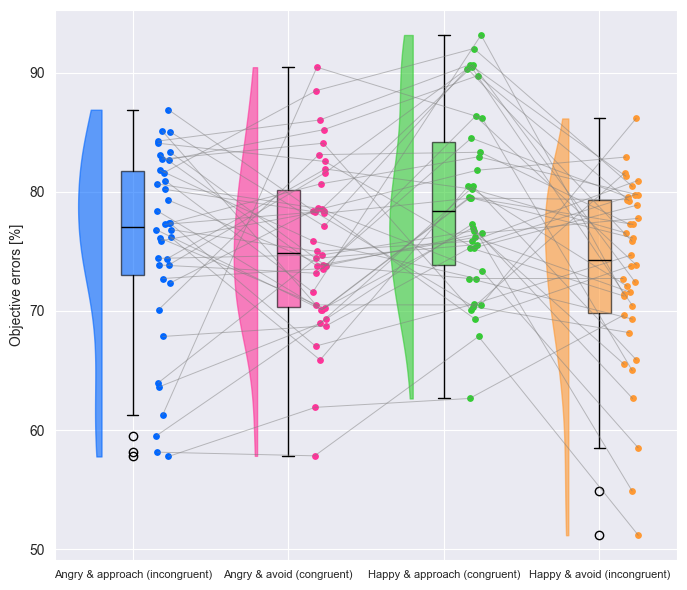

In [34]:
# Comparing overall congruency and volatility performance interaction
# Single-pass aggregation & reshape
combined_results_pivoted = combined_results_dataframe[combined_results_dataframe['volatility'] == 'stable']
combined_results_pivoted = (
    combined_results_pivoted
    .pivot_table(
        index=['subject_id', 'session'],
        columns=['valence','correct_response_boolean'],
        values='objectively_correct_boolean',
        aggfunc='mean'
    )
    .reset_index()
)
combined_results_pivoted.columns = [
    f"{a}_{b}" if b else a
    for a, b in combined_results_pivoted.columns
]
print(combined_results_pivoted)

# Plot the four groups using a raincloud plot
utils.plotting_functions.paired_raincloud_4_groups(
    combined_results_pivoted,
    columns=['angry_-1','angry_1','happy_-1','happy_1'],
    labels=['Angry & approach (incongruent)','Angry & avoid (congruent)','Happy & approach (congruent)','Happy & avoid (incongruent)'],
    output_dir=output_dir,
    ylabel_name='Objective errors [%]',
    plot_name='all_trials_accuracy_stable',
    plot_title='Errors correct response stable',
    plot_full_width=False
)

# Now do the same thing but split them for congruency & volatility

In [35]:
# Check if a block is volatile or stable
dataframe = combined_results_dataframe.sort_values(by=['subject_id', 'session', 'stimuli_type', 'trial'], ascending=[True, True, True, True])

# Create new plots with different intervals that also contain the 50% trials
mapping = {0: 'subject_id', 1: 'stimuli_type', 2: 'congruency', 3: 'volatility', 4: 0, 5: 1, 6: 2, 7: 3, 8: 4, 9: 5, 10: 6}
group_name = 'volatility'
unique_group_types = dataframe[group_name].unique()


dataframe = utils.analysis_functions.find_reversals_in_dataframe(dataframe, unique_subject_ids, unique_stimuli_types,
                                                                'volatility', plot_range, mapping, 'congruency')

#print(dataframe)

      subject_id  trial  stimuli_type  probability_condition  reversal  \
0        sub-005      8             1                     20     False   
1        sub-005     11             1                     20     False   
2        sub-005     12             1                     20     False   
3        sub-005     14             1                     20     False   
4        sub-005     15             1                     20     False   
...          ...    ...           ...                    ...       ...   
24843    sub-038    659             2                     20     False   
24844    sub-038    660             2                     20     False   
24845    sub-038    661             2                     20     False   
24846    sub-038    665             2                     20     False   
24847    sub-038    666             2                     20     False   

      volatility   congruency  
0       volatile  incongruent  
1       volatile  incongruent  
2       volatil

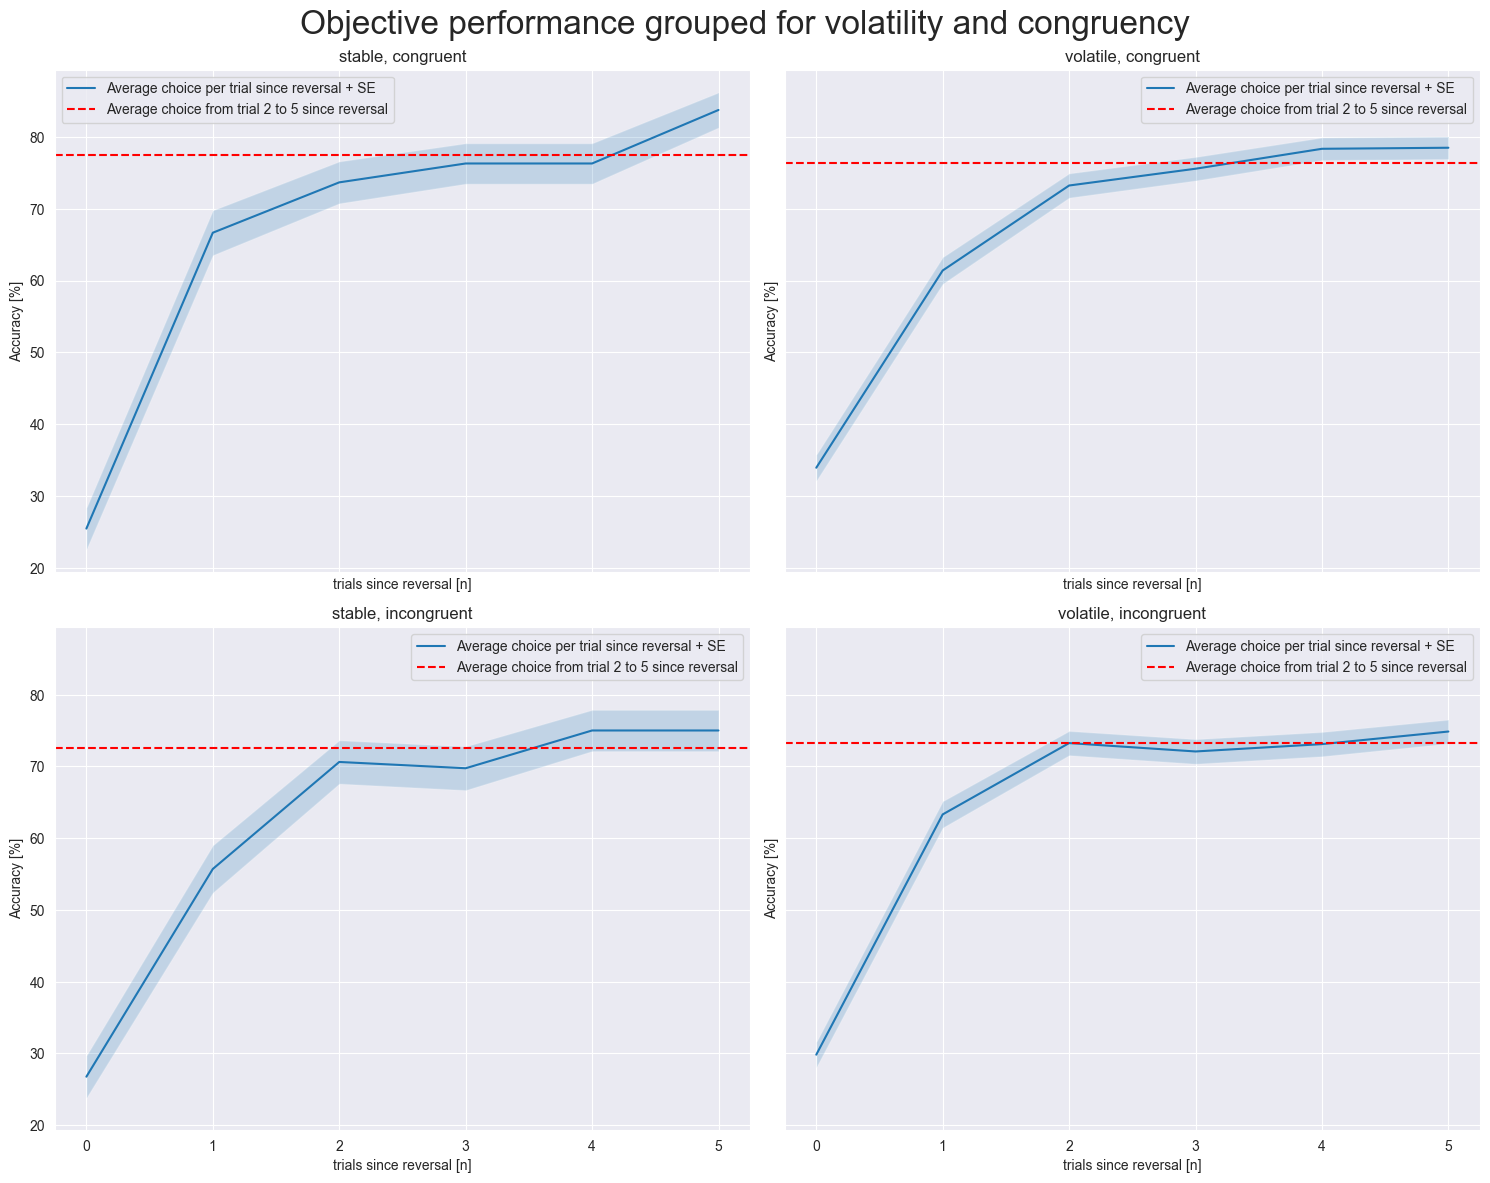

In [36]:
# Prepare the DataFrame by setting 'stimuli_type' as the index temporarily
df = dataframe

# We are not using 'subject_id', so let's exclude it from our calculations
df = df.drop(columns=['subject_id', 'stimuli_type'])

# Calculate the mean and standard deviation for each timepoint and stimuli_type
means = df.groupby(['congruency', 'volatility']).mean()
means_overall = means.iloc[:, 2:]
average_choice_after_reversal_total = means_overall.mean(axis=1).tolist()

stds = df.groupby(['congruency', 'volatility']).sem()

# Plotting
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(15, 12), sharex=True, sharey=True) # Adjust based on the number of stimuli_types
axs = axs.flatten() # Flatten to iterate easily

fig.suptitle('Objective performance grouped for volatility and congruency', fontsize=24, y=0.982)

congruency_list = df['congruency'].unique()
volatility_list = df['volatility'].unique()

congruency_types = means.index
for i, congruency_type in enumerate(congruency_types):
    # Timepoints are the column names converted to integers for x-axis values
    timepoints = list(range(plot_range[0], plot_range[1]))
    mean_values = means.loc[congruency_type]
    std_values = stds.loc[congruency_type]

    axs[i].plot(timepoints, mean_values, label='Average choice per trial since reversal + SE')
    axs[i].fill_between(timepoints, mean_values - std_values, mean_values + std_values, alpha=0.2)
    axs[i].axhline((average_choice_after_reversal_total[i]), color='r', linestyle='--', label='Average choice from trial 2 to 5 since reversal')
    #axs[i].plot(probability_dataframe_pivoted[i+1].dropna())
    axs[i].set_title(f'{congruency_type[1]}, {congruency_type[0]}')
    axs[i].set_xlabel('trials since reversal [n]')
    axs[i].set_ylabel('Accuracy [%]')
    axs[i].legend()
    axs[i].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'objective_performance_grouped_for_volatility_and_congruency.pdf'))
plt.show()

In [37]:
# Now do the same thing but split them for congruency & volatility
# Check if a block is volatile or stable
dataframe = combined_results_dataframe.sort_values(by=['subject_id', 'session', 'stimuli_type', 'trial'],
                                                   ascending=[True, True, True, True])

# Create new plots with different intervals that also contain the 50% trials
mapping = {0: 'subject_id', 1: 'stimuli_type', 2: 'congruency', 3: 'volatility', 4: 0, 5: 1, 6: 2, 7: 3, 8: 4, 9: 5,
           10: 6}
group_name = 'volatility'
unique_group_types = dataframe[group_name].unique()

dataframe = utils.analysis_functions.find_reversals_in_dataframe(dataframe, unique_subject_ids, unique_stimuli_types,
                                                                 'volatility', plot_range, mapping, 'congruency')

#print(dataframe)

      subject_id  trial  stimuli_type  probability_condition  reversal  \
0        sub-005      8             1                     20     False   
1        sub-005     11             1                     20     False   
2        sub-005     12             1                     20     False   
3        sub-005     14             1                     20     False   
4        sub-005     15             1                     20     False   
...          ...    ...           ...                    ...       ...   
24843    sub-038    659             2                     20     False   
24844    sub-038    660             2                     20     False   
24845    sub-038    661             2                     20     False   
24846    sub-038    665             2                     20     False   
24847    sub-038    666             2                     20     False   

      volatility   congruency  
0       volatile  incongruent  
1       volatile  incongruent  
2       volatil

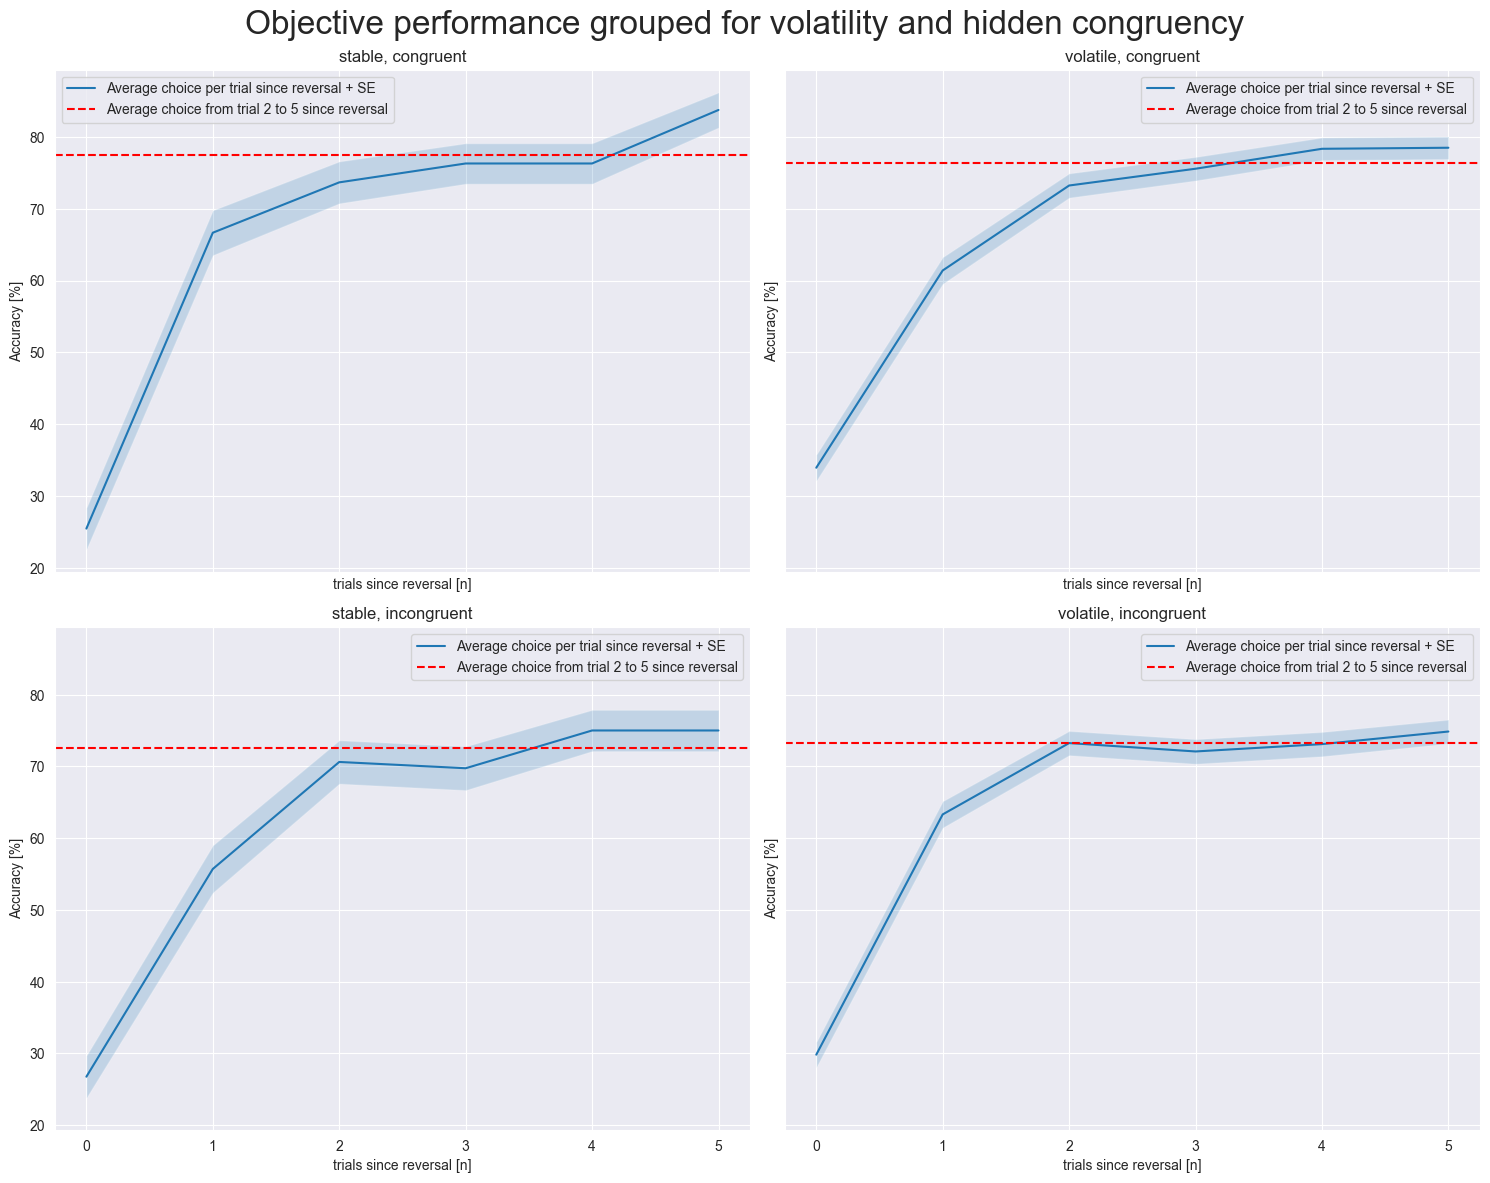

In [38]:
# Prepare the DataFrame by setting 'stimuli_type' as the index temporarily
df = dataframe

# We are not using 'subject_id', so let's exclude it from our calculations
df = df.drop(columns=['subject_id', 'stimuli_type'])

# Calculate the mean and standard deviation for each timepoint and stimuli_type
means = df.groupby(['congruency', 'volatility']).mean()
means_overall = means.iloc[:, 2:]
average_choice_after_reversal_total = means_overall.mean(axis=1).tolist()

stds = df.groupby(['congruency', 'volatility']).sem()

# Plotting
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(15, 12), sharex=True, sharey=True) # Adjust based on the number of stimuli_types
axs = axs.flatten() # Flatten to iterate easily

fig.suptitle('Objective performance grouped for volatility and hidden congruency', fontsize=24, y=0.982)

congruency_list = df['congruency'].unique()
volatility_list = df['volatility'].unique()

congruency_types = means.index
for i, congruency_type in enumerate(congruency_types):
    # Timepoints are the column names converted to integers for x-axis values
    timepoints = list(range(plot_range[0], plot_range[1]))
    mean_values = means.loc[congruency_type]
    std_values = stds.loc[congruency_type]

    axs[i].plot(timepoints, mean_values, label='Average choice per trial since reversal + SE')
    axs[i].fill_between(timepoints, mean_values - std_values, mean_values + std_values, alpha=0.2)
    axs[i].axhline((average_choice_after_reversal_total[i]), color='r', linestyle='--', label='Average choice from trial 2 to 5 since reversal')
    #axs[i].plot(probability_dataframe_pivoted[i+1].dropna())
    axs[i].set_title(f'{congruency_type[1]}, {congruency_type[0]}')
    axs[i].set_xlabel('trials since reversal [n]')
    axs[i].set_ylabel('Accuracy [%]')
    axs[i].legend()
    axs[i].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'objective_performance_grouped_for_volatility_and_congruency.pdf'))
plt.show()

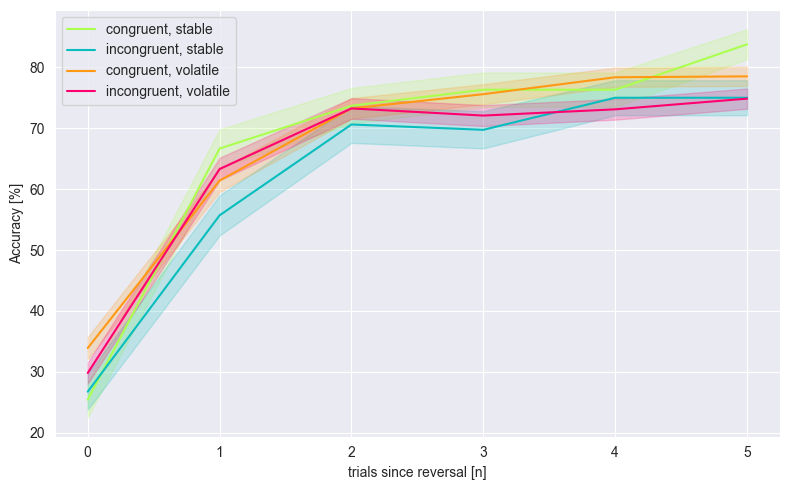

In [39]:
df_long = dataframe.melt(
    id_vars=['subject_id', 'stimuli_type', 'volatility', 'congruency'],
    value_vars=[0, 1, 2, 3, 4, 5],
    var_name='time',
    value_name='value'
)
# Convert the time column to integers
df_long['time'] = df_long['time'].astype(int)

# Compute mean and standard error of the mean (SEM)
summary = (
    df_long
    .groupby(['volatility', 'congruency', 'time'])['value']
    .agg(['mean', 'sem'])
    .reset_index()
)

colour = ['#ABFF4F','#08BDBD','#FF9914','#FF006E']

# 3) Plot with shaded error bands
fig, ax = plt.subplots(figsize=(8, 5))
for idx, ((vol, cong), grp) in enumerate(summary.groupby(['volatility', 'congruency'])):
    x = grp['time']
    y = grp['mean']
    yerr = grp['sem']
    # draw the line
    line, = ax.plot(
        x, y,
        label=f'{cong}, {vol}',
        color=colour[idx],
    )
    # use same colour for the fill, with transparency
    #colour = line.get_color()
    ax.fill_between(
        x,
        y - yerr,
        y + yerr,
        color=colour[idx],
        alpha=0.2
    )

ax.set_xlabel('trials since reversal [n]')
ax.set_ylabel('Accuracy [%]')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'objective_performance_combined_for_volatility_and_congruency.pdf'))
plt.show()

# Plot the full stable block

In [40]:
# Check if a block is volatile or stable
dataframe = combined_results_dataframe.sort_values(by=['subject_id', 'session', 'stimuli_type', 'trial'], ascending=[True, True, True, True])

# Create a dictionary based on the plot range
initial_columns = {0: 'subject_id', 1: 'stimuli_type', 2: 'volatility'}
adjusted_plot_range = [0, 28]
# Append the plot range to the existing dictionary
mapping = initial_columns.copy()
mapping.update({k+3: v for k, v in enumerate(plot_range)})

# Define the to be plotted factor
group_name = 'volatility'
unique_group_types = dataframe[group_name].unique()

dataframe = utils.analysis_functions.find_reversals_in_dataframe(dataframe, unique_subject_ids, unique_stimuli_types,
                                                                'volatility', adjusted_plot_range, mapping)

print(dataframe)

      subject_id  trial  stimuli_type  probability_condition  reversal  \
0        sub-005      8             1                     20     False   
1        sub-005     11             1                     20     False   
2        sub-005     12             1                     20     False   
3        sub-005     14             1                     20     False   
4        sub-005     15             1                     20     False   
...          ...    ...           ...                    ...       ...   
24843    sub-038    659             2                     20     False   
24844    sub-038    660             2                     20     False   
24845    sub-038    661             2                     20     False   
24846    sub-038    665             2                     20     False   
24847    sub-038    666             2                     20     False   

      volatility  
0       volatile  
1       volatile  
2       volatile  
3       volatile  
4       volatile

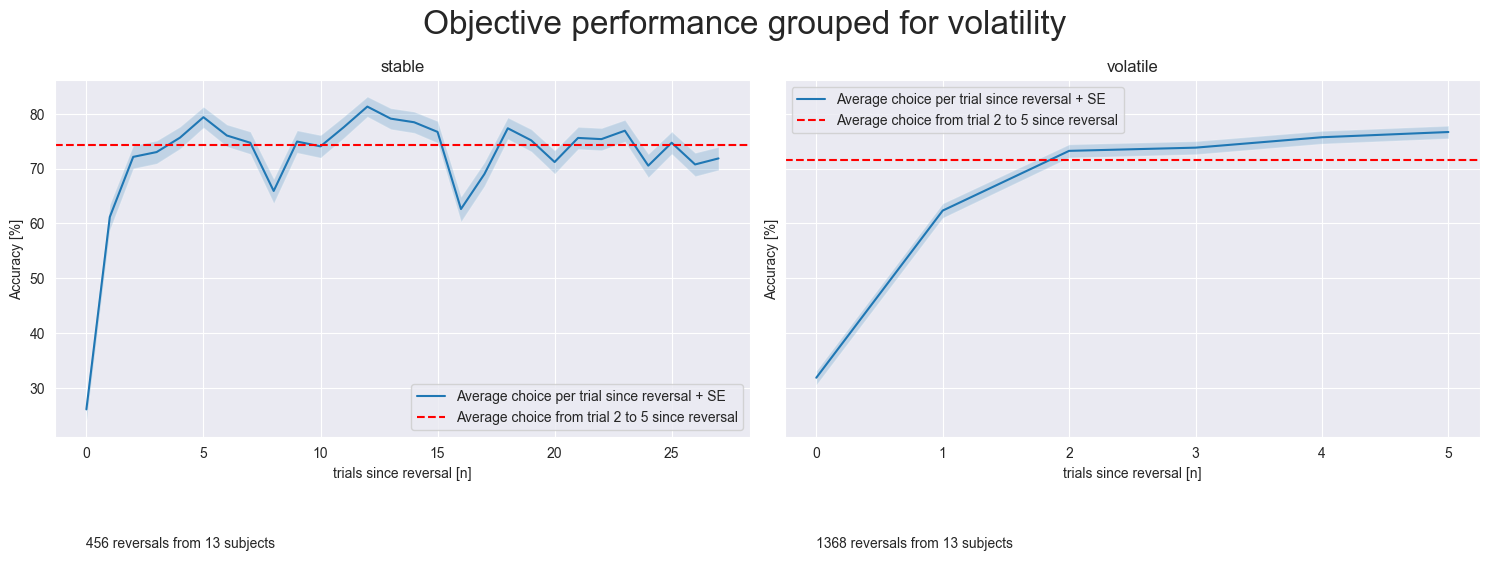

In [41]:
# Remove volatile rows
df = dataframe.set_index('volatility')

subject_counts = len(df['subject_id'].unique())

# Count the number of times both conditions were shown
group_counts = df.index.value_counts()

# We are not using 'subject_id', so let's exclude it from our calculations
df = df.drop(columns=['subject_id'])
df = df.drop(columns=['stimuli_type'])

# Calculate the mean and standard deviation for each timepoint and stimuli_type
means = df.groupby('volatility').mean()
means_overall = means.iloc[:, 2:]
average_choice_after_reversal_total = (means_overall.mean(axis=1).tolist())
stds = df.groupby('volatility').sem()

# Plotting
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15, 6), sharex=False, sharey=True) # Adjust based on the number of stimuli_types
axs = axs.flatten() # Flatten to iterate easily

fig.suptitle('Objective performance grouped for volatility', fontsize=24, y=0.982)

congruency_list = dataframe['volatility'].unique()

congruency_types = means.index
for i, congruency_type in enumerate(congruency_types):
    # Timepoints are the column names converted to integers for x-axis values

    mean_values = means.loc[congruency_type]
    std_values = stds.loc[congruency_type]
    
    if congruency_type == 'stable':
        timepoints = list(range(adjusted_plot_range[0], adjusted_plot_range[1]))
    else:
        volatile_duration = 6
        timepoints = list(range(0, volatile_duration))
        mean_values = mean_values.iloc[:volatile_duration]
        std_values = std_values.iloc[:volatile_duration]

    axs[i].plot(timepoints, mean_values, label='Average choice per trial since reversal + SE')
    axs[i].fill_between(timepoints, mean_values - std_values, mean_values + std_values, alpha=0.2)
    axs[i].axhline(average_choice_after_reversal_total[i], color='r', linestyle='--', label='Average choice from trial 2 to 5 since reversal')
    #axs[i].plot(probability_dataframe_pivoted[i+1].dropna())
    axs[i].set_title(congruency_list[i])
    axs[i].set_xlabel('trials since reversal [n]')
    axs[i].set_ylabel('Accuracy [%]')
    axs[i].text(0, 0.82, f'{group_counts[congruency_type]} reversals from {subject_counts} subjects', fontsize=10)
    axs[i].legend()
    axs[i].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'objective_performance_for_full_stable_block.pdf'))
plt.show()

In [42]:
# Check if a block is volatile or stable
dataframe = combined_results_dataframe.sort_values(by=['subject_id', 'session', 'stimuli_type', 'trial'], ascending=[True, True, True, True])

# Then bin the area around a reversal
adjusted_plot_range = [plot_range[0] - plot_range[1], plot_range[1] - 1]
dataframe = utils.analysis_functions.bin_responses_for_congruency(dataframe, adjusted_plot_range, 'volatility')

# Map transitions to congruency
to_flip = {
    'happy_congruent_to_incongruent',
    'happy_incongruent_to_congruent'
}

# build a boolean mask for rows to flip
mask = dataframe['emotional_valence_and_transition'].isin(to_flip)

# apply the flip
dataframe.loc[mask, 'response_int'] = 100 - dataframe.loc[mask, 'response_int']

# define your mapping
mapping = {
    'angry_congruent_to_incongruent':    'congruent_to_incongruent',
    'happy_incongruent_to_congruent':    'incongruent_to_congruent',
    'angry_incongruent_to_congruent':    'incongruent_to_congruent',
    'happy_congruent_to_incongruent':    'congruent_to_incongruent',
    'angry_no_transition':               'no_transition',
    'happy_no_transition':               'no_transition',
}

# create new column
dataframe['transitions_combined'] = (
    dataframe['emotional_valence_and_transition']
     .map(mapping)
     .fillna('unknown')   # optional: catch any unexpected values
)

print(dataframe)

[0, 30, 62, 68, 76, 82, 90, 96, 106, 138, 166, 174, 183, 189, 195, 205, 213, 242, 270, 276, 286, 293, 303, 311, 321, 327, 357, 389, 395, 403, 409, 417, 423, 433, 465, 493, 501, 511, 517, 523, 532, 540, 570, 598, 604, 614, 622, 632, 640, 650, 686, 716, 722, 732, 742, 749, 759, 765, 797, 829, 837, 847, 853, 861, 871, 879, 907, 935, 945, 951, 957, 965, 973, 979, 985, 1014, 1044, 1050, 1060, 1070, 1078, 1088, 1094, 1125, 1157, 1164, 1174, 1180, 1188, 1198, 1206, 1233, 1261, 1271, 1277, 1283, 1291, 1299, 1305, 1311, 1321, 1331, 1339, 1347, 1355, 1361, 1389, 1419, 1429, 1439, 1449, 1457, 1463, 1471, 1501, 1533, 1539, 1545, 1553, 1563, 1569, 1575, 1603, 1635, 1641, 1651, 1661, 1669, 1677, 1685, 1691, 1719, 1749, 1759, 1769, 1779, 1787, 1793, 1801, 1831, 1863, 1869, 1875, 1883, 1893, 1899, 1905, 1933, 1965, 1971, 1981, 1987, 1997, 2003, 2011, 2021, 2053, 2083, 2091, 2099, 2105, 2115, 2122, 2130, 2160, 2188, 2196, 2202, 2212, 2222, 2228, 2234, 2266, 2294, 2300, 2310, 2315, 2325, 2331, 2339, 234

# Still needs fix where only transitions of volatile to volatile and stable to stable are used

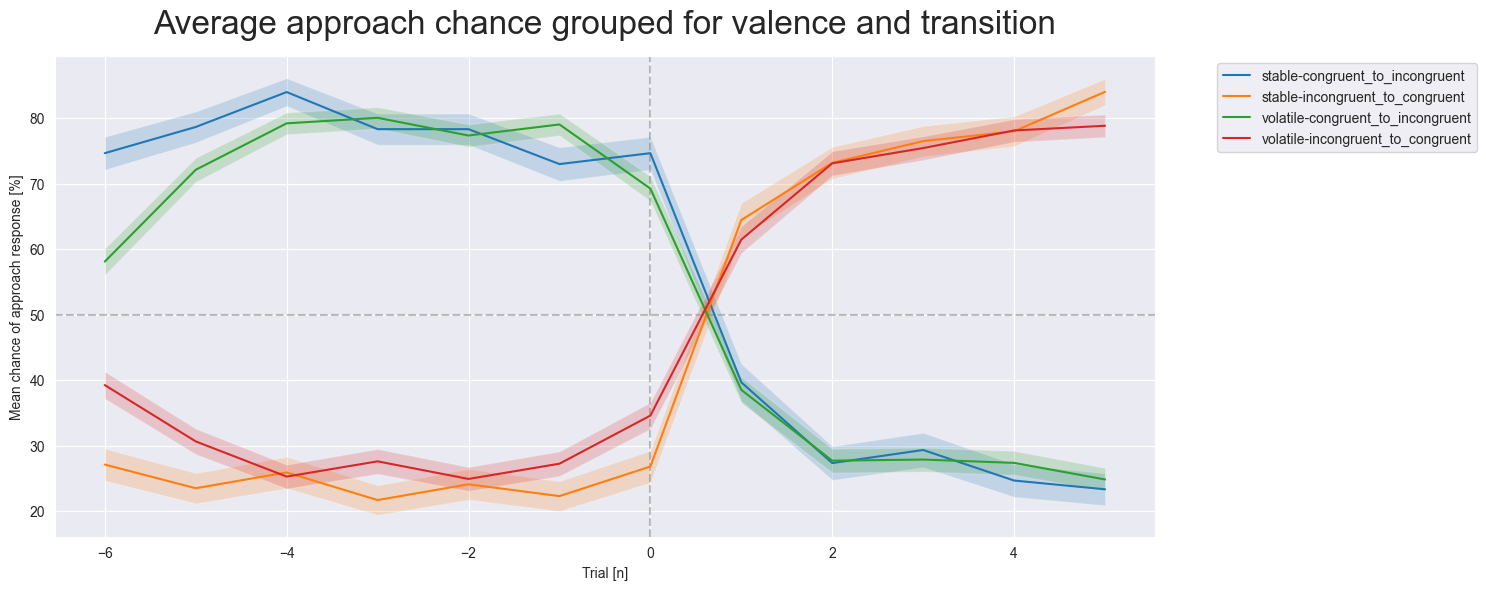

In [43]:
# Group the data
grouped_dataframe = dataframe.groupby(['trials_around_reversal', 'volatility', 'transitions_combined'])['response_int'].agg(['mean', 'sem']).reset_index()

# Plotting with Matplotlib
plt.figure(figsize=(15, 6))

# Define the unique groups for 'emotional_valence' and 'transition'
emotional_valences = grouped_dataframe['volatility'].unique()
transitions = grouped_dataframe['transitions_combined'].unique()
transitions = [s for s in transitions if 'no_transition' not in s]

# Plot each group
plt.axhline(50, color='grey', linestyle='dashed', alpha=0.5)
plt.axvline(0, color='grey', linestyle='dashed', alpha=0.5)
for valence in emotional_valences:
    for transition in transitions:
        subset = grouped_dataframe[(grouped_dataframe['volatility'] == valence) & (grouped_dataframe['transitions_combined'] == transition)]
        current_emotion = subset['volatility'].unique()
        current_transition = subset['transitions_combined'].unique()
        if not subset.empty:
            plt.plot(subset['trials_around_reversal'], subset['mean'], label=f'{valence}-{transition}')
            plt.fill_between(subset['trials_around_reversal'], subset['mean'] - subset['sem'], subset['mean'] + subset['sem'], alpha=0.2)

# Customize the plot
plt.xlabel('Trial [n]')
plt.ylabel('Approach chance [%]')
plt.title('Average approach chance grouped for valence and transition', fontsize=24, y=1.03)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()

plt.savefig(os.path.join(output_dir, 'average_approach_chance_grouped_for_volatility_and_transition.pdf'))
# Show the plot
plt.show()

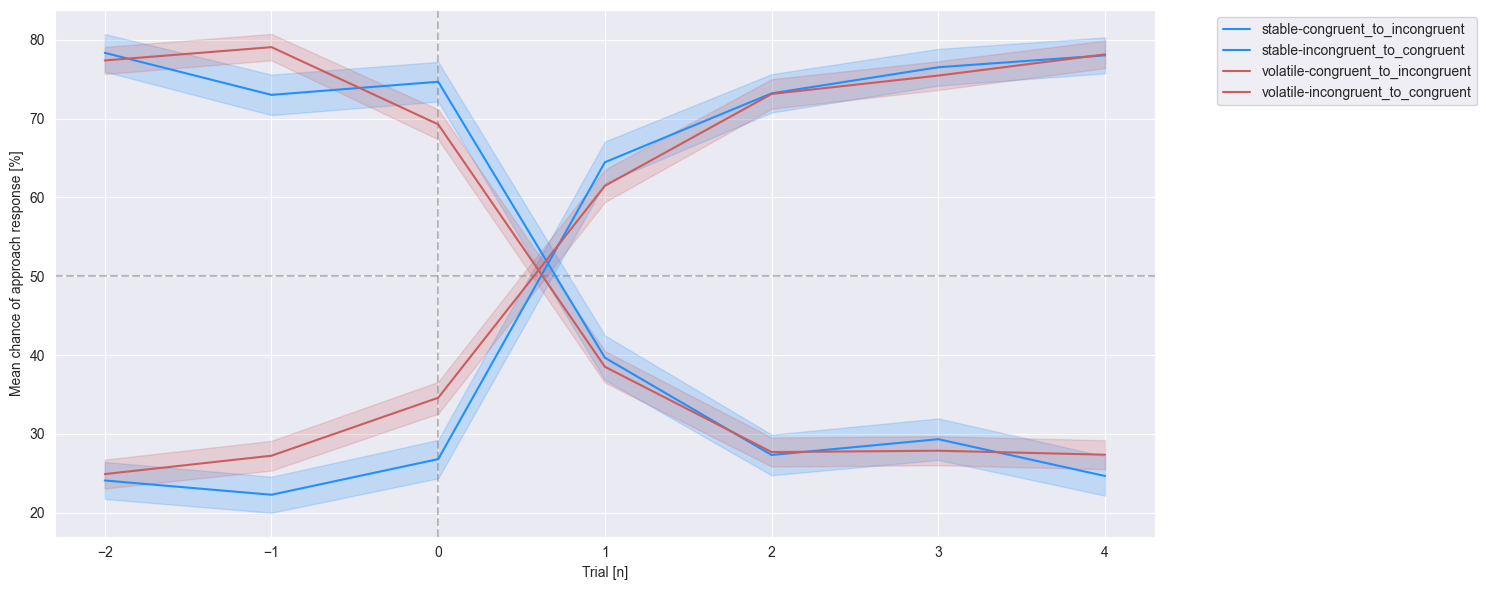

In [50]:
# Zoom in on the window from trial -1 to 2
subset_dataframe = dataframe[(dataframe['trials_around_reversal'] >= -2) &
                      (dataframe['trials_around_reversal'] <= 4)]

# Group the data
grouped_dataframe = subset_dataframe.groupby(['trials_around_reversal', 'volatility', 'transitions_combined'])['response_int'].agg(['mean', 'sem']).reset_index()

# Plotting with Matplotlib
plt.figure(figsize=(15, 6))

# Define the unique groups for 'emotional_valence' and 'transition'
emotional_valences = grouped_dataframe['volatility'].unique()
transitions = grouped_dataframe['transitions_combined'].unique()
transitions = [s for s in transitions if 'no_transition' not in s]

colors = ['dodgerblue', 'dodgerblue', 'indianred', 'indianred']
color_index = 0

# Plot each group
plt.axhline(50, color='grey', linestyle='dashed', alpha=0.5)
plt.axvline(0, color='grey', linestyle='dashed', alpha=0.5)
for valence in emotional_valences:
    for transition in transitions:
        subset = grouped_dataframe[(grouped_dataframe['volatility'] == valence) & (grouped_dataframe['transitions_combined'] == transition)]
        current_emotion = subset['volatility'].unique()
        current_transition = subset['transitions_combined'].unique()
        if not subset.empty:
            plt.plot(subset['trials_around_reversal'], subset['mean'], label=f'{valence}-{transition}', color=colors[color_index])
            plt.fill_between(subset['trials_around_reversal'], subset['mean'] - subset['sem'], subset['mean'] + subset['sem'], alpha=0.2, color=colors[color_index])

        color_index += 1

# Customize the plot
plt.xlabel('Trial [n]')
plt.ylabel('Approach chance [%]')
#plt.title('Average approach chance grouped for volatility and transition', fontsize=24, y=1.03)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()

plt.savefig(os.path.join(output_dir, 'average_approach_chance_grouped_for_volatility_and_transition_zoomed.pdf'))
# Show the plot
plt.show()

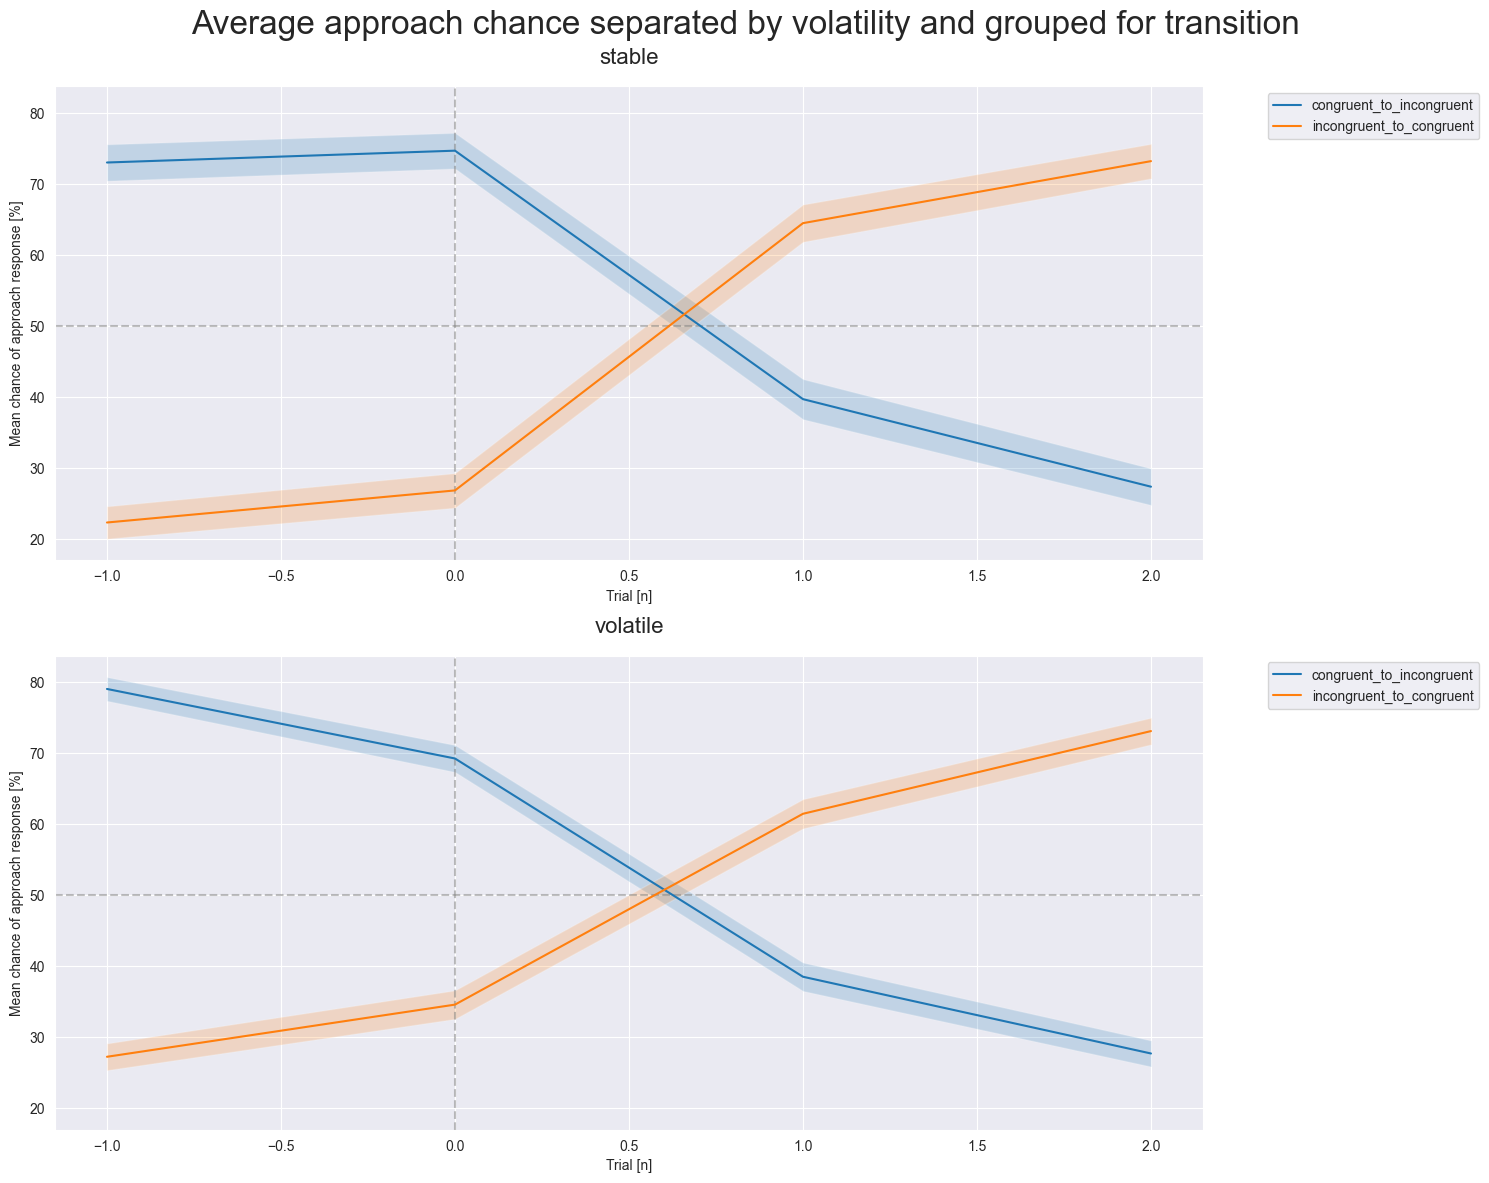

In [45]:
# Plotting with Matplotlib
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(15, 12), sharey=True)

fig.suptitle('Average approach chance separated by volatility and grouped for transition', fontsize=24, y=0.982)

# Plot each group
for valence_index, valence_value in enumerate(emotional_valences):
    axes[valence_index].axhline(50, color='grey', linestyle='dashed', alpha=0.5)
    axes[valence_index].axvline(0, color='grey', linestyle='dashed', alpha=0.5)
    for transition in transitions:
        subset = grouped_dataframe[(grouped_dataframe['volatility'] == valence_value) & (grouped_dataframe['transitions_combined'] == transition)]
        current_emotion = subset['volatility'].unique()
        current_transition = subset['transitions_combined'].unique()
        if not subset.empty:
            axes[valence_index].plot(subset['trials_around_reversal'], subset['mean'], label=f'{transition}')
            axes[valence_index].fill_between(subset['trials_around_reversal'], subset['mean'] - subset['sem'], subset['mean'] + subset['sem'], alpha=0.2)

    # Customize the plot
    axes[valence_index].set_xlabel('Trial [n]')
    axes[valence_index].set_ylabel('Approach chance [%]')
    axes[valence_index].set_title(valence_value, fontsize=16, y=1.03)
    axes[valence_index].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.grid(True)
plt.tight_layout()

plt.savefig(os.path.join(output_dir, 'average_approach_chance_separated_by_volatility_and_grouped_for_transition.pdf'))
# Show the plot
plt.show()

# Overall objective performance over time
This will be used to check whether their performance stabilises after the 1st session

In [46]:
all_session_labels = ['session-01', 'session-02', 'session-03', 'session-04']
if all(s in unique_sessions for s in all_session_labels):
    # Check if a block is volatile or stable
    dataframe = combined_results_dataframe_all_sessions[combined_results_dataframe_all_sessions['probability_condition'] != 50]
    dataframe = utils.analysis_functions.check_volatility(dataframe)
    dataframe = dataframe.sort_values(by=['subject_id', 'session', 'stimuli_type', 'trial'], ascending=[True, True, True, True])

    # Single-pass aggregation & reshape
    combined_results_pivoted = dataframe[dataframe['trials_since_reversal'] != 0]
    combined_results_pivoted = (
        combined_results_pivoted
        .pivot_table(
            index=['subject_id', 'session'],
            columns=['congruency', 'volatility'],
            values='objectively_correct_boolean',
            aggfunc='mean'
        )
        .reset_index()
    )
    combined_results_pivoted.columns = [
        f"{a}_{b}" if b else a
        for a, b in combined_results_pivoted.columns
    ]
    print(combined_results_pivoted)

    # Plot the two groups using a raincloud plot
    utils.plotting_functions.paired_scatter_violin_box_2x2(
        combined_results_pivoted,
        columns=['congruent_stable','incongruent_stable','congruent_volatile','incongruent_volatile'],
        subject_col='subject_id',
        session_col='session',
        labels=['Stable & congruent','Stable & incongruent','Volatile & congruent','Volatile & incongruent'],
        output_dir=output_dir,
        ylabel_name='Accuracy [%]',
        plot_name='all_trials_objective_performance_comparing_congruency_and_volatility'
    )